In [202]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns
from statsmodels.stats.multitest import multipletests

from utils.autocorrelation_per_state import autocorrelation_per_state # Import custom autoccorelation function


import geopandas as gpd
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches


In [203]:
# Needed Columns for the Hypothesis testing
#data_needed = ["Order Date", "Category", "Revenue", "Shipping Address State", "tavg"]

df_granger_fashion = pd.read_csv("./data/fashion_data.csv")
df_granger_fashion["Order Date"] = pd.to_datetime(df_granger_fashion["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
df_granger_fashion.set_index("Order Date", inplace=True)
df_granger_fashion.drop(columns=["Unnamed: 0"], inplace=True)


df_granger_grocerie = pd.read_csv("./data/grocery_data.csv")
df_granger_grocerie["Order Date"] = pd.to_datetime(df_granger_grocerie["Order Date"])
df_granger_grocerie.set_index("Order Date", inplace=True)
df_granger_grocerie.drop(columns=["Unnamed: 0"], inplace=True)

## Functional implementation of Granger Causation Matrix

In [204]:
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):
    maxlag = 12    
    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

In [205]:
# List of states
states_list = df_granger_grocerie["Shipping Address State"].unique()

# Base Granger tests

## Fashion Granger Test: Revenue lagged by one day - Temperature

In [206]:
state_p_values_fashion = {}
p_values_fashion_list = []

for i in range(len(states_list)): 
    try: 
        # Create subset of only one State
        df_one_state = df_granger_fashion[df_granger_fashion["Shipping Address State"].isin([states_list[i]])].copy()

        # Remove Seasonality from Temperature
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

        df_one_state["Revenue_lagged1"] = df_one_state["Revenue"].shift(1)
        # Remove values for 2017; We only needed them for Removing Seasonality in 2018 and dont have transactiosn for that year
        df_one_state = df_one_state.iloc[365:, ]

        #Define first order Diff for Revenue
        first_order_diff = [0]

        # Calc first order diff
        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        # Append to main df 
        df_one_state["first_order_diff_Revenue"] = first_order_diff


        # Perfrom granger test on variables first order diff and temperature no season
        granger_matrix = grangers_causation_matrix(df_one_state ,variables=["Revenue_lagged1", "tavg"])

        # Collect p-values from returned matrix
        p_value = granger_matrix.iloc[0, 1]

        # Save states p-value in final df
        state_p_values_fashion[states_list[i]] = p_value
        p_values_fashion_list.append(p_value)

        #print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    


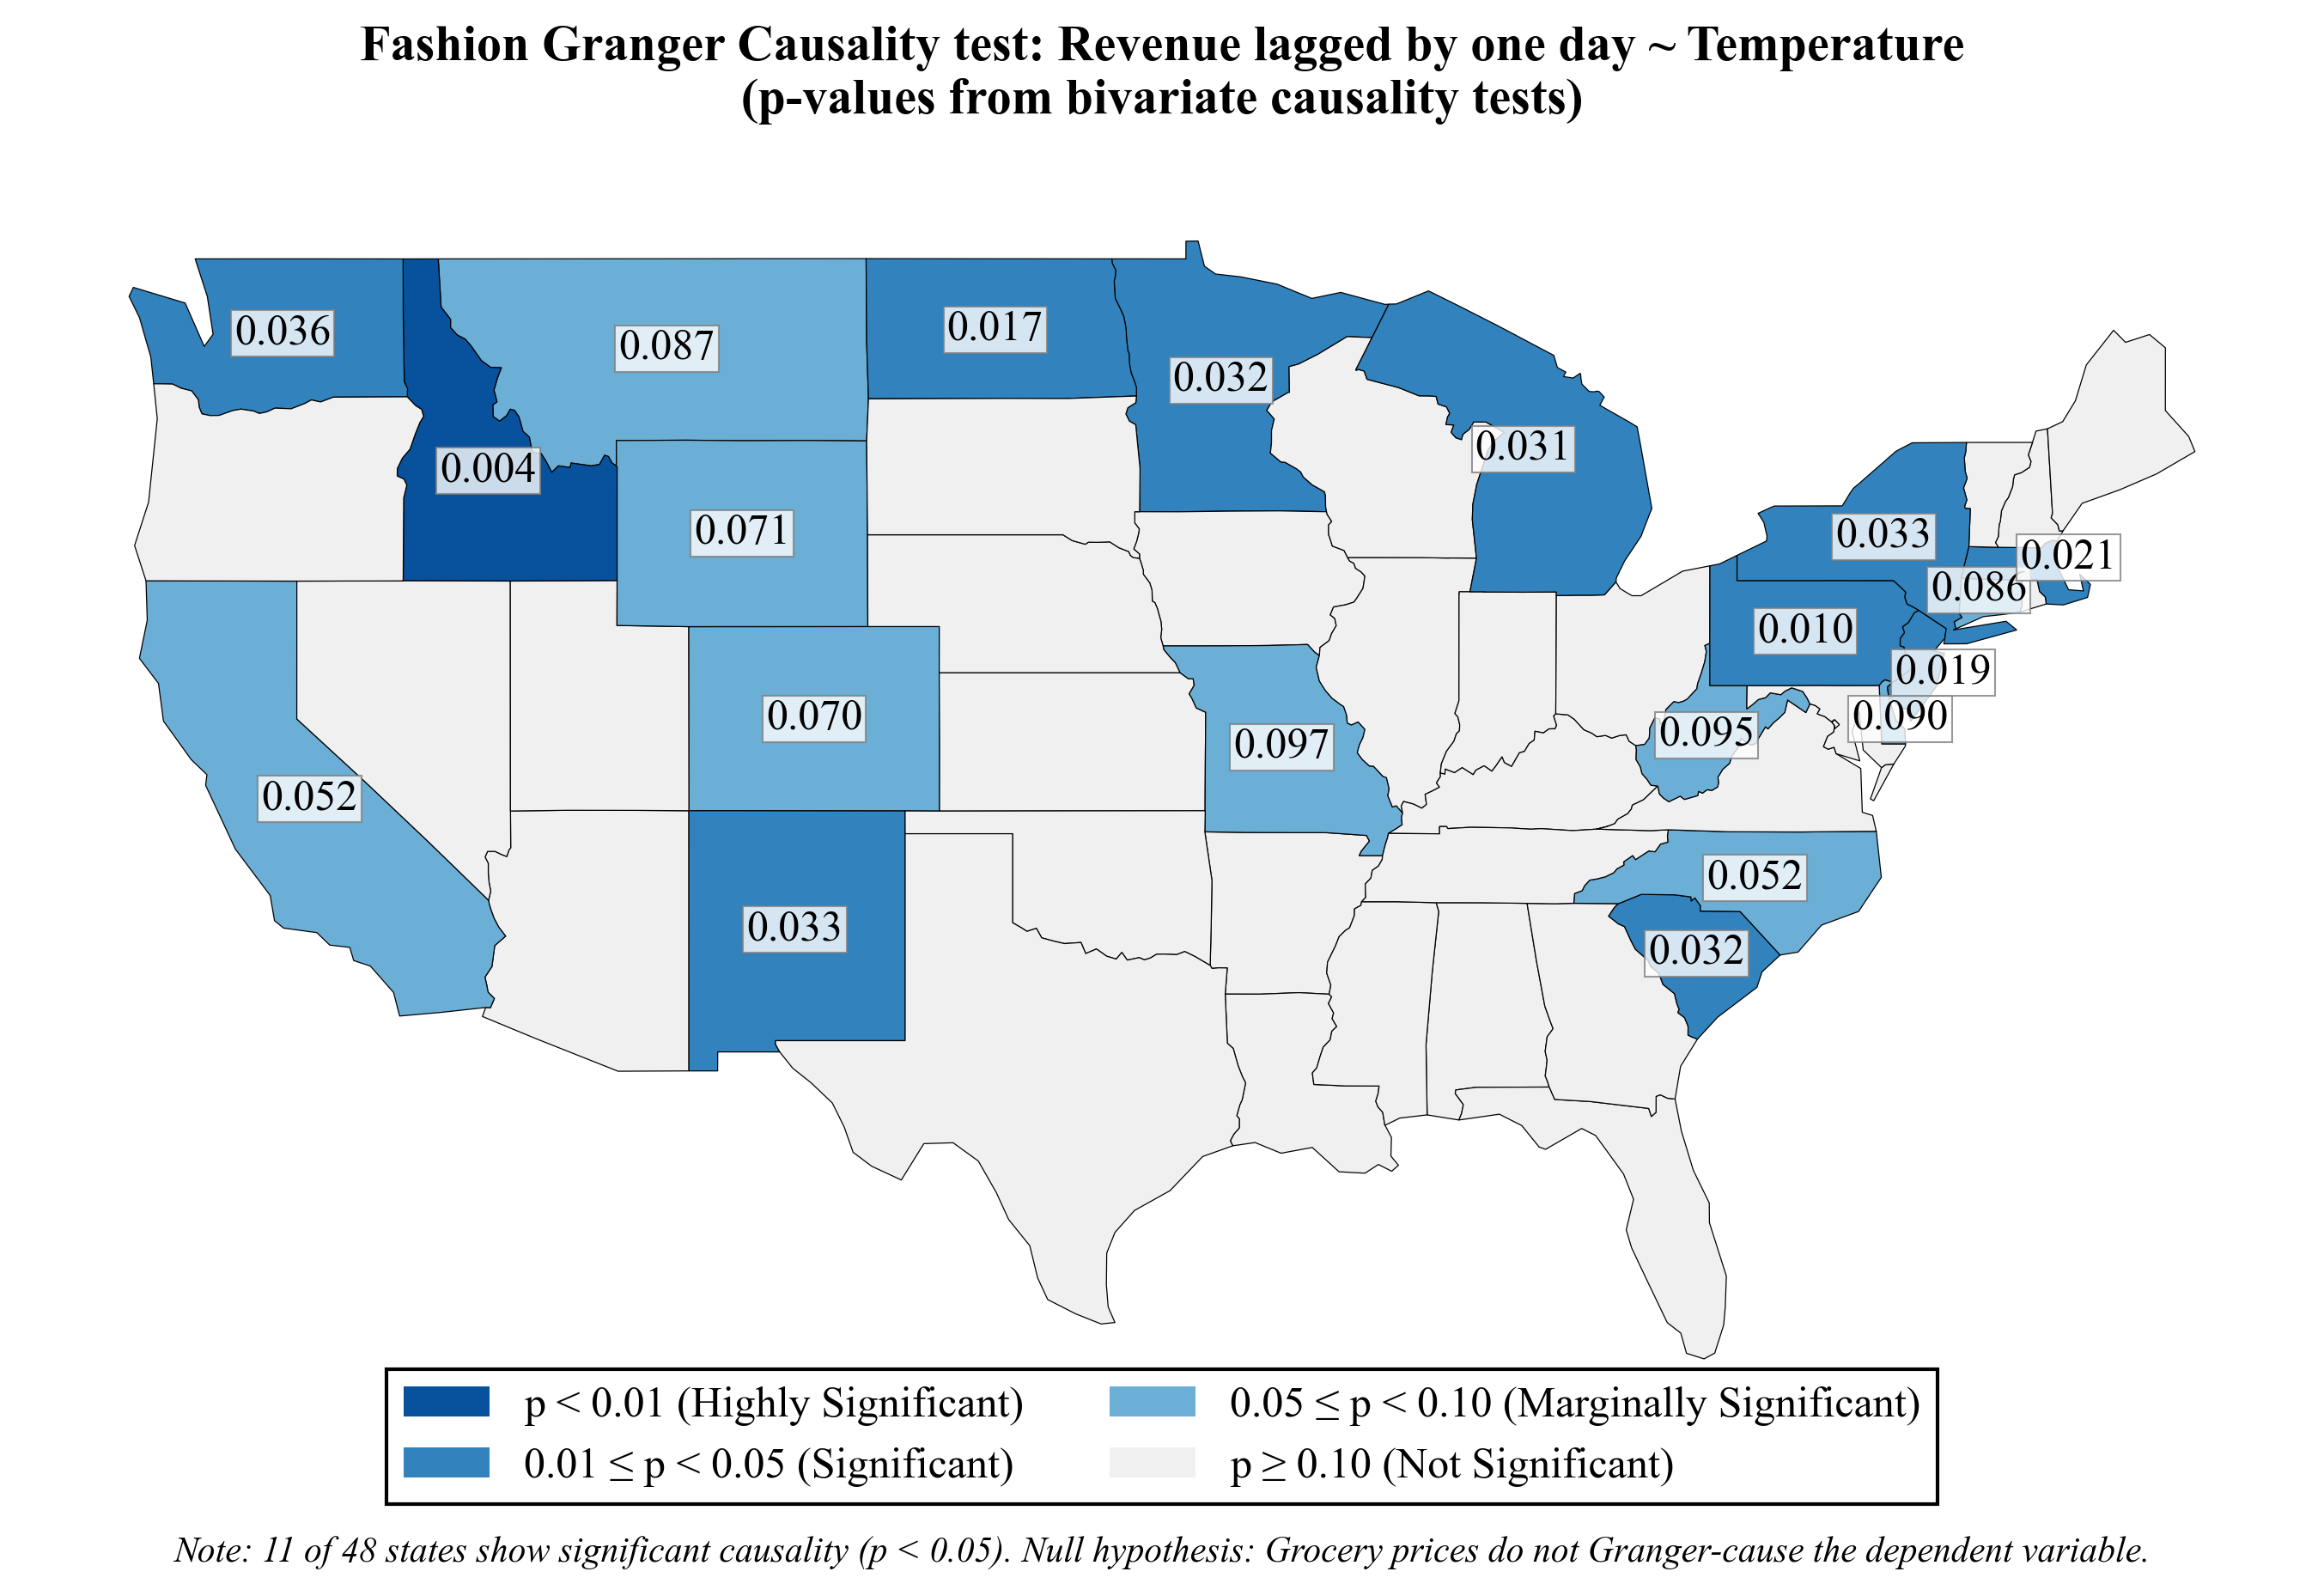

In [207]:
# Styling
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.linewidth': 0.8,
    'figure.dpi': 300
})

# Convert p-values to DataFrame
p_value_df = pd.DataFrame.from_dict(state_p_values_fashion, orient='index', columns=['p_value'])
p_value_df.index.name = 'state'

# Load and prepare geographic data
usa = gpd.read_file('./Map_USA/ne_110m_admin_1_states_provinces.shp')
usa = usa[~usa['postal'].isin(['AK', 'HI'])]  # Exclude Alaska and Hawaii
usa['state'] = usa['postal']
usa = usa.merge(p_value_df, on='state', how='left')

# Create figure with proper dimensions for academic publication
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Define significance levels and colors
significance_levels = [0, 0.01, 0.05, 0.10, 1.0]
colors = ['#08519c', '#3182bd', '#6baed6', '#f0f0f0']
cmap = plt.matplotlib.colors.ListedColormap(colors)
norm = BoundaryNorm(significance_levels, cmap.N)

# Create the choropleth map
usa.plot(column='p_value',
         cmap=cmap,
         norm=norm,
         ax=ax,
         legend=False,
         edgecolor='black',
         linewidth=0.3,
         missing_kwds={'color': '#f0f0f0', 'edgecolor': 'black', 'linewidth': 0.3})

# Define manual positions for overlapping East Coast states
manual_positions = {
    'CT': (-73, 41.8),    # Connecticut - move slightly east
    'RI': (-71.0, 40.9),    # Rhode Island - move east
    'MA': (-70.5, 42.5),    # Massachusetts - move northeast  
    'VT': (-72.8, 44.2),    # Vermont - move slightly west
    'NH': (-71.2, 43.8),    # New Hampshire - move east
    'NJ': (-74.0, 40.0),    # New Jersey - move south
    'DE': (-75.2, 39.0),    # Delaware - move southwest
    'MD': (-76.5, 39.2),    # Maryland - move west
}

# Add state labels with p-values (smaller, cleaner format)
for idx, row in usa.iterrows():
    if not pd.isna(row['p_value']):
        # Use manual position if available, otherwise use centroid
        if row['state'] in manual_positions:
            x, y = manual_positions[row['state']]
        else:
            centroid = row.geometry.centroid
            x, y = centroid.x, centroid.y
        
        # Only show p-value if it's significant or marginally significant
        if row['p_value'] <= 0.10:
            label = f'{row["p_value"]:.3f}'
            ax.text(x, y, 
                   label,
                   horizontalalignment='center',
                   verticalalignment='center',
                   fontsize=12,
                   fontweight='normal',
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', 
                           linewidth=0.5, pad=1))

# Create custom legend
legend_elements = [
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#08519c', label='p < 0.01 (Highly Significant)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#3182bd', label='0.01 ≤ p < 0.05 (Significant)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#6baed6', label='0.05 ≤ p < 0.10 (Marginally Significant)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#f0f0f0', label='p ≥ 0.10 (Not Significant)'),
    #mpatches.Rectangle((0, 0), 1, 1, facecolor='#f0f0f0', label='No Data')
]

# Position legend outside the plot area
legend = ax.legend(handles=legend_elements, 
                  loc='lower center',
                  bbox_to_anchor=(0.5, -0.09),  # Center horizontally, below the plot
                  ncol=2,  # Number of columns (adjust based on your legend items)
                  frameon=True,
                  fancybox=False,
                  shadow=False,
                  framealpha=1,
                  edgecolor='black',
                  facecolor='white')

# Set title with proper academic formatting
ax.set_title('Fashion Granger Causality test: Revenue lagged by one day ~ Temperature\n(p-values from bivariate causality tests)',
             fontsize=14, 
             fontweight='bold',
             pad=20)

# Remove axes
ax.set_axis_off()

# Add statistical summary as subtitle
total_states = len(usa[~usa['p_value'].isna()])
significant_states = len(usa[usa['p_value'] <= 0.05])
ax.text(0.5, -0.12, 
        f'Note: {significant_states} of {total_states} states show significant causality (p < 0.05). '
        f'Null hypothesis: Grocery prices do not Granger-cause the dependent variable.',
        transform=ax.transAxes,
        fontsize=10,
        ha='center',
        style='italic')

# Adjust layout to accommodate legend
plt.tight_layout()
plt.subplots_adjust(right=0.75)

# Save options for thesis
#plt.savefig('granger_causality_fashion.pdf', dpi=300, bbox_inches='tight')
plt.savefig('./Exports/granger_causality_fashion.png', dpi=300, bbox_inches='tight')

plt.show()

## Groceries Granger Test: Revenue lagged by one day - Temperature

In [208]:
state_p_values_grocerie = {}
p_values_grocieries_list = []

for i in range(len(states_list)): 
    try: 
        # Create subset of only one State
        df_one_state = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin([states_list[i]])].copy()

        # Remove Seasonality from Temperature
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

        df_one_state["Revenue_lagged1"] = df_one_state["Revenue"].shift(1)
        # Remove values for 2017; We only needed them for Removing Seasonality in 2018 and dont have transactiosn for that year
        df_one_state = df_one_state.iloc[365:, ]

        #Define first order Diff for Revenue
        first_order_diff = [0]

        # Calc first order diff
        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        # Append to main df 
        df_one_state["first_order_diff_Revenue"] = first_order_diff


        # Perfrom granger test on variables first order diff and temperature no season
        granger_matrix = grangers_causation_matrix(df_one_state ,variables=["Revenue_lagged1", "tavg"])

        # Collect p-values from returned matrix
        p_value = granger_matrix.iloc[0, 1]

        # Save states p-value in final df
        state_p_values_grocerie[states_list[i]] = p_value
        p_values_grocieries_list.append(p_value)

        #print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    


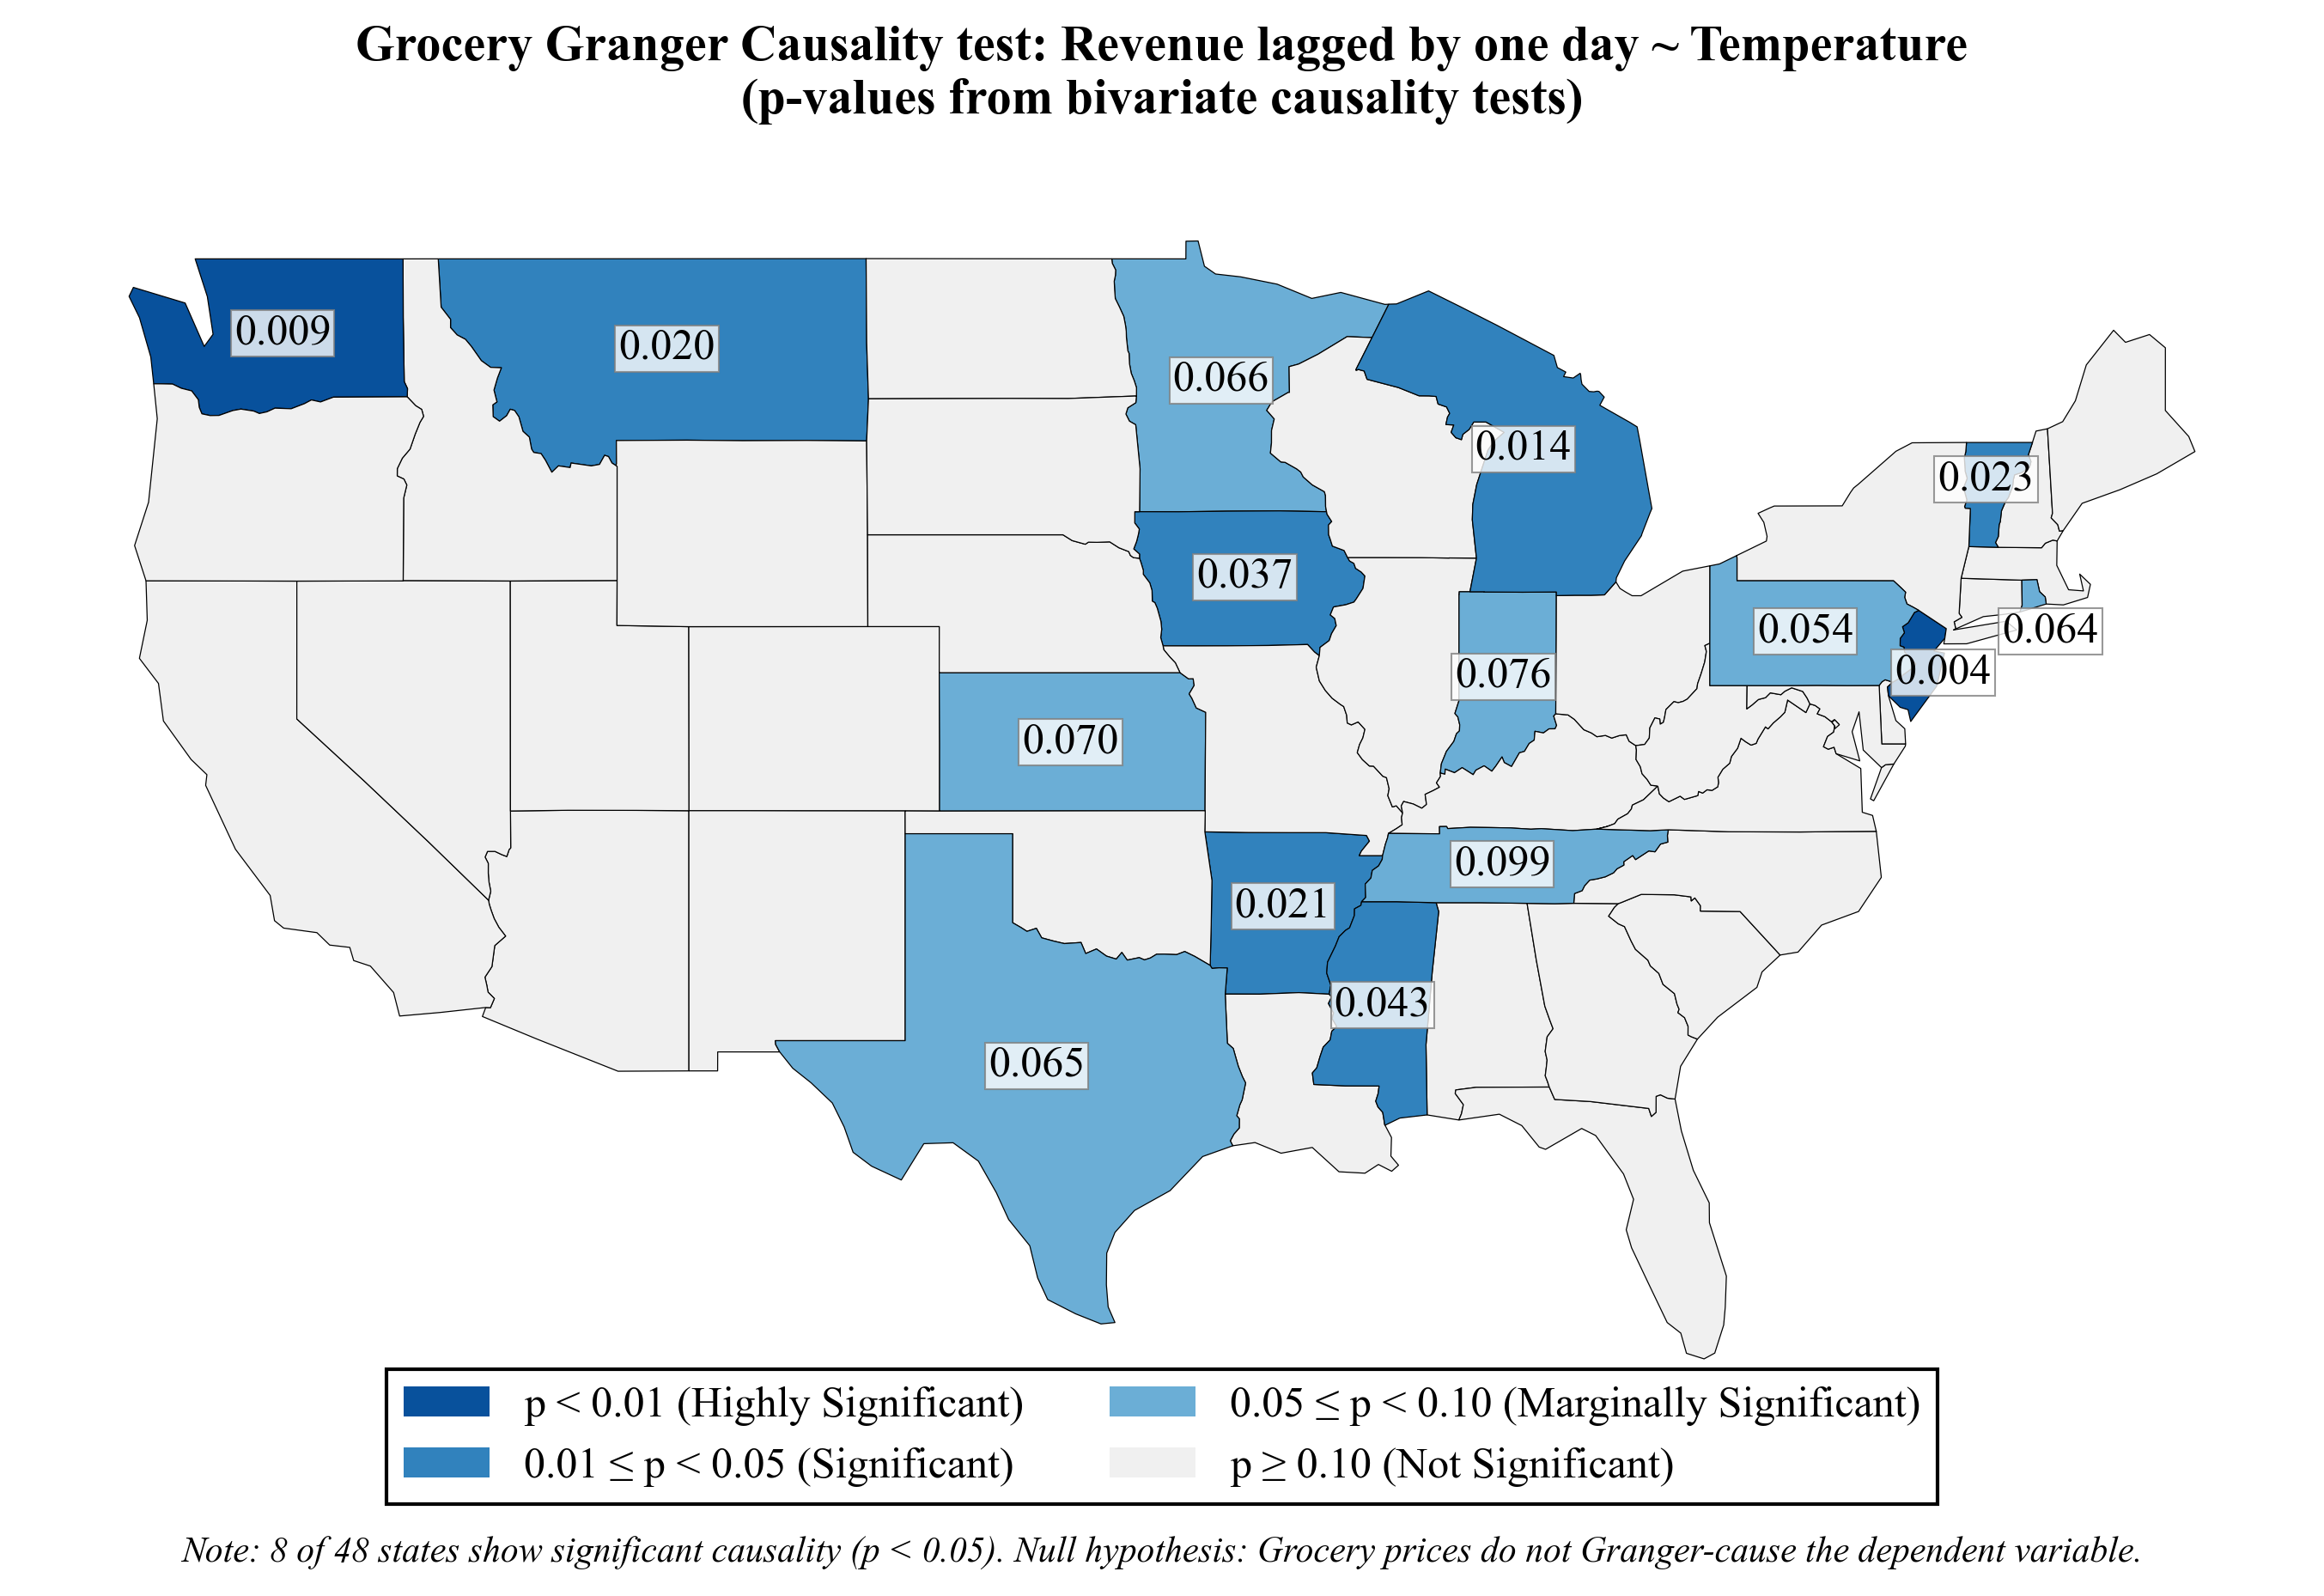

In [209]:
# Styling
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.linewidth': 0.8,
    'figure.dpi': 300
})

# Convert p-values to DataFrame
p_value_df = pd.DataFrame.from_dict(state_p_values_grocerie, orient='index', columns=['p_value'])
p_value_df.index.name = 'state'

# Load and prepare geographic data
usa = gpd.read_file('./Map_USA/ne_110m_admin_1_states_provinces.shp')
usa = usa[~usa['postal'].isin(['AK', 'HI'])]  # Exclude Alaska and Hawaii
usa['state'] = usa['postal']
usa = usa.merge(p_value_df, on='state', how='left')

# Create figure with proper dimensions for academic publication
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Define significance levels and colors
significance_levels = [0, 0.01, 0.05, 0.10, 1.0]
colors = ['#08519c', '#3182bd', '#6baed6', '#f0f0f0']
cmap = plt.matplotlib.colors.ListedColormap(colors)
norm = BoundaryNorm(significance_levels, cmap.N)

# Create the choropleth map
usa.plot(column='p_value',
         cmap=cmap,
         norm=norm,
         ax=ax,
         legend=False,
         edgecolor='black',
         linewidth=0.3,
         missing_kwds={'color': '#f0f0f0', 'edgecolor': 'black', 'linewidth': 0.3})

# Define manual positions for overlapping East Coast states
manual_positions = {
    'CT': (-73, 41.8),    # Connecticut - move slightly east
    'RI': (-71.0, 40.9),    # Rhode Island - move east
    'MA': (-70.5, 42.5),    # Massachusetts - move northeast  
    'VT': (-72.8, 44.2),    # Vermont - move slightly west
    'NH': (-71.2, 43.8),    # New Hampshire - move east
    'NJ': (-74.0, 40.0),    # New Jersey - move south
    'DE': (-75.2, 39.0),    # Delaware - move southwest
    'MD': (-76.5, 39.2),    # Maryland - move west
}

# Add state labels with p-values (smaller, cleaner format)
for idx, row in usa.iterrows():
    if not pd.isna(row['p_value']):
        # Use manual position if available, otherwise use centroid
        if row['state'] in manual_positions:
            x, y = manual_positions[row['state']]
        else:
            centroid = row.geometry.centroid
            x, y = centroid.x, centroid.y
        
        # Only show p-value if it's significant or marginally significant
        if row['p_value'] <= 0.10:
            label = f'{row["p_value"]:.3f}'
            ax.text(x, y, 
                   label,
                   horizontalalignment='center',
                   verticalalignment='center',
                   fontsize=12,
                   fontweight='normal',
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', 
                           linewidth=0.5, pad=1))

# Create custom legend
legend_elements = [
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#08519c', label='p < 0.01 (Highly Significant)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#3182bd', label='0.01 ≤ p < 0.05 (Significant)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#6baed6', label='0.05 ≤ p < 0.10 (Marginally Significant)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#f0f0f0', label='p ≥ 0.10 (Not Significant)'),
    #mpatches.Rectangle((0, 0), 1, 1, facecolor='#f0f0f0', label='No Data')
]

# Position legend outside the plot area
legend = ax.legend(handles=legend_elements, 
                  loc='lower center',
                  bbox_to_anchor=(0.5, -0.09),  # Center horizontally, below the plot
                  ncol=2,  # Number of columns (adjust based on your legend items)
                  frameon=True,
                  fancybox=False,
                  shadow=False,
                  framealpha=1,
                  edgecolor='black',
                  facecolor='white')

# Set title with proper academic formatting
ax.set_title('Grocery Granger Causality test: Revenue lagged by one day ~ Temperature\n(p-values from bivariate causality tests)',
             fontsize=14, 
             fontweight='bold',
             pad=20)

# Remove axes
ax.set_axis_off()

# Add statistical summary as subtitle
total_states = len(usa[~usa['p_value'].isna()])
significant_states = len(usa[usa['p_value'] <= 0.05])
ax.text(0.5, -0.12, 
        f'Note: {significant_states} of {total_states} states show significant causality (p < 0.05). '
        f'Null hypothesis: Grocery prices do not Granger-cause the dependent variable.',
        transform=ax.transAxes,
        fontsize=10,
        ha='center',
        style='italic')

# Adjust layout to accommodate legend
plt.tight_layout()
plt.subplots_adjust(right=0.75)

# Save options for thesis
#plt.savefig('granger_causality_groceries.pdf', dpi=300, bbox_inches='tight')
plt.savefig('./Exports/granger_causality_groceries.png', dpi=300, bbox_inches='tight')

plt.show()

## Fashion Granger Test: First order diff for Revenue - Temp no seasonality

In [210]:
"""state_p_values_fashion = {}
p_values_fashion_list = []

for i in range(len(states_list)): 
    try: 
        df_one_state = df_granger_fashion[df_granger_fashion["Shipping Address State"].isin([states_list[i]])].copy()

        # Remove Seasonality from Temp
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

        df_one_state = df_one_state.iloc[365:, ]

        #Fist order Diff for Revenue
        first_order_diff = [0]

        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        df_one_state["first_order_diff_Revenue"] = first_order_diff
    
        granger_matrix = grangers_causation_matrix(df_one_state ,variables=["first_order_diff_Revenue", "Temp_No_Season"])

        p_value = granger_matrix.iloc[0, 1]
        state_p_values_fashion[states_list[i]] = p_value
        p_values_fashion_list.append(p_value)

        #print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    
"""

'state_p_values_fashion = {}\np_values_fashion_list = []\n\nfor i in range(len(states_list)): \n    try: \n        df_one_state = df_granger_fashion[df_granger_fashion["Shipping Address State"].isin([states_list[i]])].copy()\n\n        # Remove Seasonality from Temp\n        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)\n        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)\n\n        df_one_state = df_one_state.iloc[365:, ]\n\n        #Fist order Diff for Revenue\n        first_order_diff = [0]\n\n        for j in range(1,len(df_one_state)): \n            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])\n\n        df_one_state["first_order_diff_Revenue"] = first_order_diff\n    \n        granger_matrix = grangers_causation_matrix(df_one_state ,variables=["first_order_diff_Revenue", "Temp_No_Season"])\n\n        p_value = granger_matrix.iloc[0, 1]\n        state_p_values_fas

# Implementation of Multiple Error Adjustments via Benjamini-Hochberg method

In [211]:
# 1. Order p-values largest -> smallest 
# 2. Compare against threshold 
# 2.2 Threshold: p(1) compare against alpha/n
        # p(2) compare alpha/n-1
# 3. Procedure stops at first non-significant results 



reject, adj_pvals = multipletests(p_values_grocieries_list, alpha=0.1, method='fdr_bh', is_sorted = False)[:2]
#print("Groceries Category \n")
#print(reject)
#print("-------------")
#print(adj_pvals)

state_p_values_grocerie_adj = {}
for i in range(len(states_list)): 
    state_p_values_grocerie_adj[states_list[i]] = adj_pvals[i]
    p_values_grocerie_adj_list = adj_pvals


reject, adj_pvals = multipletests(p_values_fashion_list, alpha=0.05, method='fdr_bh', is_sorted = False)[:2]
#print("\n Fashion Category\n")
#print(reject)
#print("-------------")
#print(adj_pvals)

state_p_values_fashion_adj = {}
for i in range(len(states_list)): 
    state_p_values_fashion_adj[states_list[i]] = adj_pvals[i]
    p_values_fashion_adj_list = adj_pvals

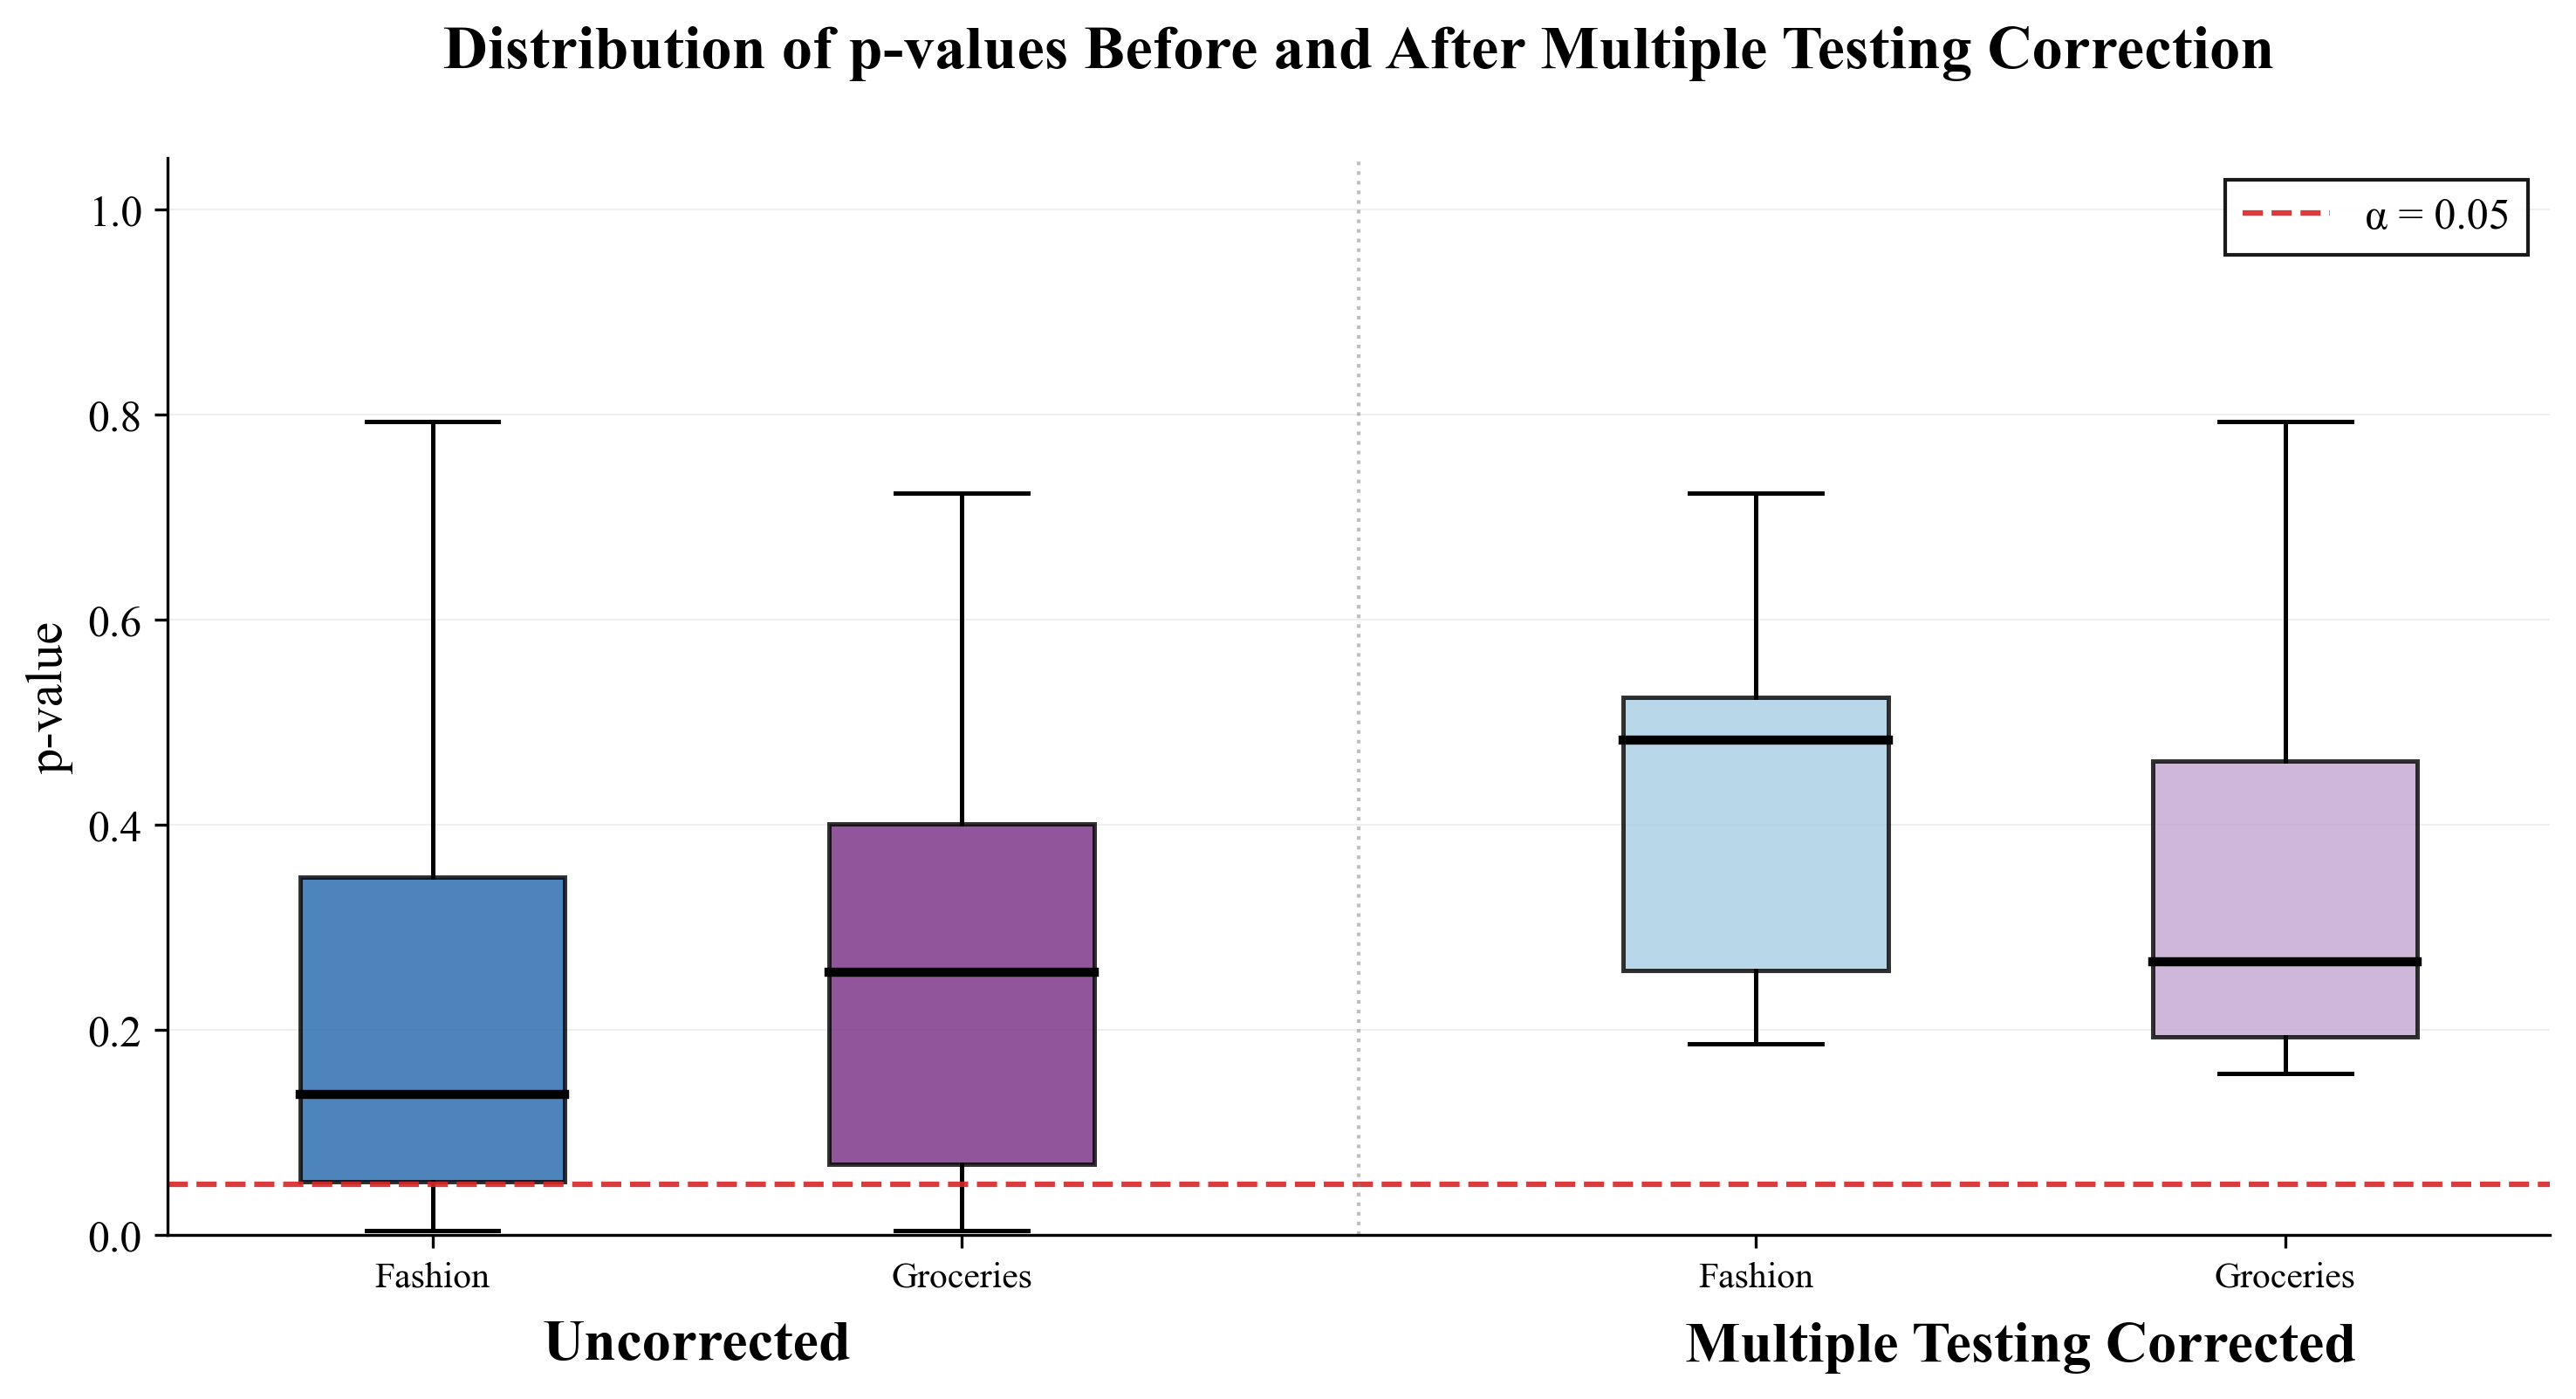

In [212]:
import matplotlib.pyplot as plt
import numpy as np

# Set publication-ready style
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.linewidth': 0.8,
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False
})

fig, ax = plt.subplots(figsize=(10, 6))

# Create positions with better spacing
positions = [1, 2, 3.5, 4.5]  # Group original and adjusted
widths = 0.5

# Professional color scheme
colors = {
    'fashion_orig': '#2166ac',     # Professional blue
    'groceries_orig': '#762a83',   # Professional purple
    'groceries_adj': '#a6cee3',    # Light purple (adjusted)
    'fashion_adj': '#c2a5cf'       # Light blue (adjusted)
}

# Create boxplots with consistent styling
box_props = dict(linewidth=1.2, alpha=0.8)
median_props = dict(linewidth=2.5, color='black')
whisker_props = dict(linewidth=1.2)
cap_props = dict(linewidth=1.2)

bp1 = ax.boxplot([p_values_fashion_list], 
                 positions=[positions[0]], 
                 widths=widths,
                 patch_artist=True,
                 boxprops={**box_props, 'facecolor': colors['fashion_orig']},
                 medianprops=median_props,
                 whiskerprops=whisker_props,
                 capprops=cap_props)

bp2 = ax.boxplot([p_values_grocieries_list], 
                 positions=[positions[1]], 
                 widths=widths,
                 patch_artist=True,
                 boxprops={**box_props, 'facecolor': colors['groceries_orig']},
                 medianprops=median_props,
                 whiskerprops=whisker_props,
                 capprops=cap_props)

bp3 = ax.boxplot([p_values_fashion_adj_list], 
                 positions=[positions[3]], 
                 widths=widths,
                 patch_artist=True,
                 boxprops={**box_props, 'facecolor': colors['fashion_adj']},
                 medianprops=median_props,
                 whiskerprops=whisker_props,
                 capprops=cap_props)


bp4 = ax.boxplot([p_values_grocerie_adj_list], 
                 positions=[positions[2]], 
                 widths=widths,
                 patch_artist=True,
                 boxprops={**box_props, 'facecolor': colors['groceries_adj']},
                 medianprops=median_props,
                 whiskerprops=whisker_props,
                 capprops=cap_props)

# Professional labels and title
ax.set_ylabel('p-value', fontsize=14, fontweight='normal')
#ax.set_xlabel('Product Category and Correction Method', fontsize=12, fontweight='normal')
ax.set_title('Distribution of p-values Before and After Multiple Testing Correction', 
             fontsize=17, fontweight='bold', pad=25)

# Clean x-axis labels
labels = ['Fashion', 'Groceries', 'Fashion', 'Groceries']
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=10)

# Add significance threshold lines with better styling
ax.axhline(y=0.05, color='#d62728', linestyle='--', linewidth=1.5, alpha=0.9, label='α = 0.05')

# Add subtle group separators
ax.axvline(x=2.75, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Professional legend
ax.legend(loc='upper right', frameon=True, fancybox=False, shadow=False, 
          framealpha=0.9, edgecolor='black', facecolor='white')

# Minimal grid
ax.grid(True, alpha=0.2, axis='y', linestyle='-', linewidth=0.5)

# Set appropriate y-axis limits
ax.set_ylim(0, 1.05)

# Add group labels
ax.text(1.5, -0.08, 'Uncorrected', ha='center', va='top', fontweight='bold', 
        transform=ax.get_xaxis_transform(), fontsize=16)
ax.text(4, -0.08, 'Multiple Testing Corrected', ha='center', va='top', fontweight='bold',
        transform=ax.get_xaxis_transform(), fontsize=16)

# Calculate and display summary statistics in a cleaner way
fashion_median = np.median(p_values_fashion_list)
groceries_median = np.median(p_values_grocieries_list)
groceries_adj_median = np.median(p_values_grocerie_adj_list)
fashion_adj_median = np.median(p_values_fashion_adj_list)

# Count significant results
fashion_sig = np.sum(np.array(p_values_fashion_list) < 0.05)
groceries_sig = np.sum(np.array(p_values_grocieries_list) < 0.05)
groceries_adj_sig = np.sum(np.array(p_values_grocerie_adj_list) < 0.05)
fashion_adj_sig = np.sum(np.array(p_values_fashion_adj_list) < 0.05)


# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Make room for the note

# Save options for thesis
# plt.savefig('granger_causality_boxplots.pdf', dpi=300, bbox_inches='tight')
plt.savefig('./Exports/granger_causality_boxplots.png', dpi=300, bbox_inches='tight')

plt.show()

# FOR APPENDIX: Granger test: Temperature no season ~ Revenue lagged by one day

## Fashion

In [213]:
state_p_values_fashion = {}
p_values_fashion_list = []

for i in range(len(states_list)): 
    try: 
        # Create subset of only one State
        df_one_state = df_granger_fashion[df_granger_fashion["Shipping Address State"].isin([states_list[i]])].copy()

        # Remove Seasonality from Temperature
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

        df_one_state["Revenue_lagged1"] = df_one_state["Revenue"].shift(1)
        # Remove values for 2017; We only needed them for Removing Seasonality in 2018 and dont have transactiosn for that year
        df_one_state = df_one_state.iloc[365:, ]

        #Define first order Diff for Revenue
        first_order_diff = [0]

        # Calc first order diff
        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        # Append to main df 
        df_one_state["first_order_diff_Revenue"] = first_order_diff


        # Perfrom granger test on variables first order diff and temperature no season
        granger_matrix = grangers_causation_matrix(df_one_state ,variables=["Revenue_lagged1", "Temp_No_Season"])

        # Collect p-values from returned matrix
        p_value = granger_matrix.iloc[0, 1]

        # Save states p-value in final df
        state_p_values_fashion[states_list[i]] = p_value
        p_values_fashion_list.append(p_value)

        #print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    


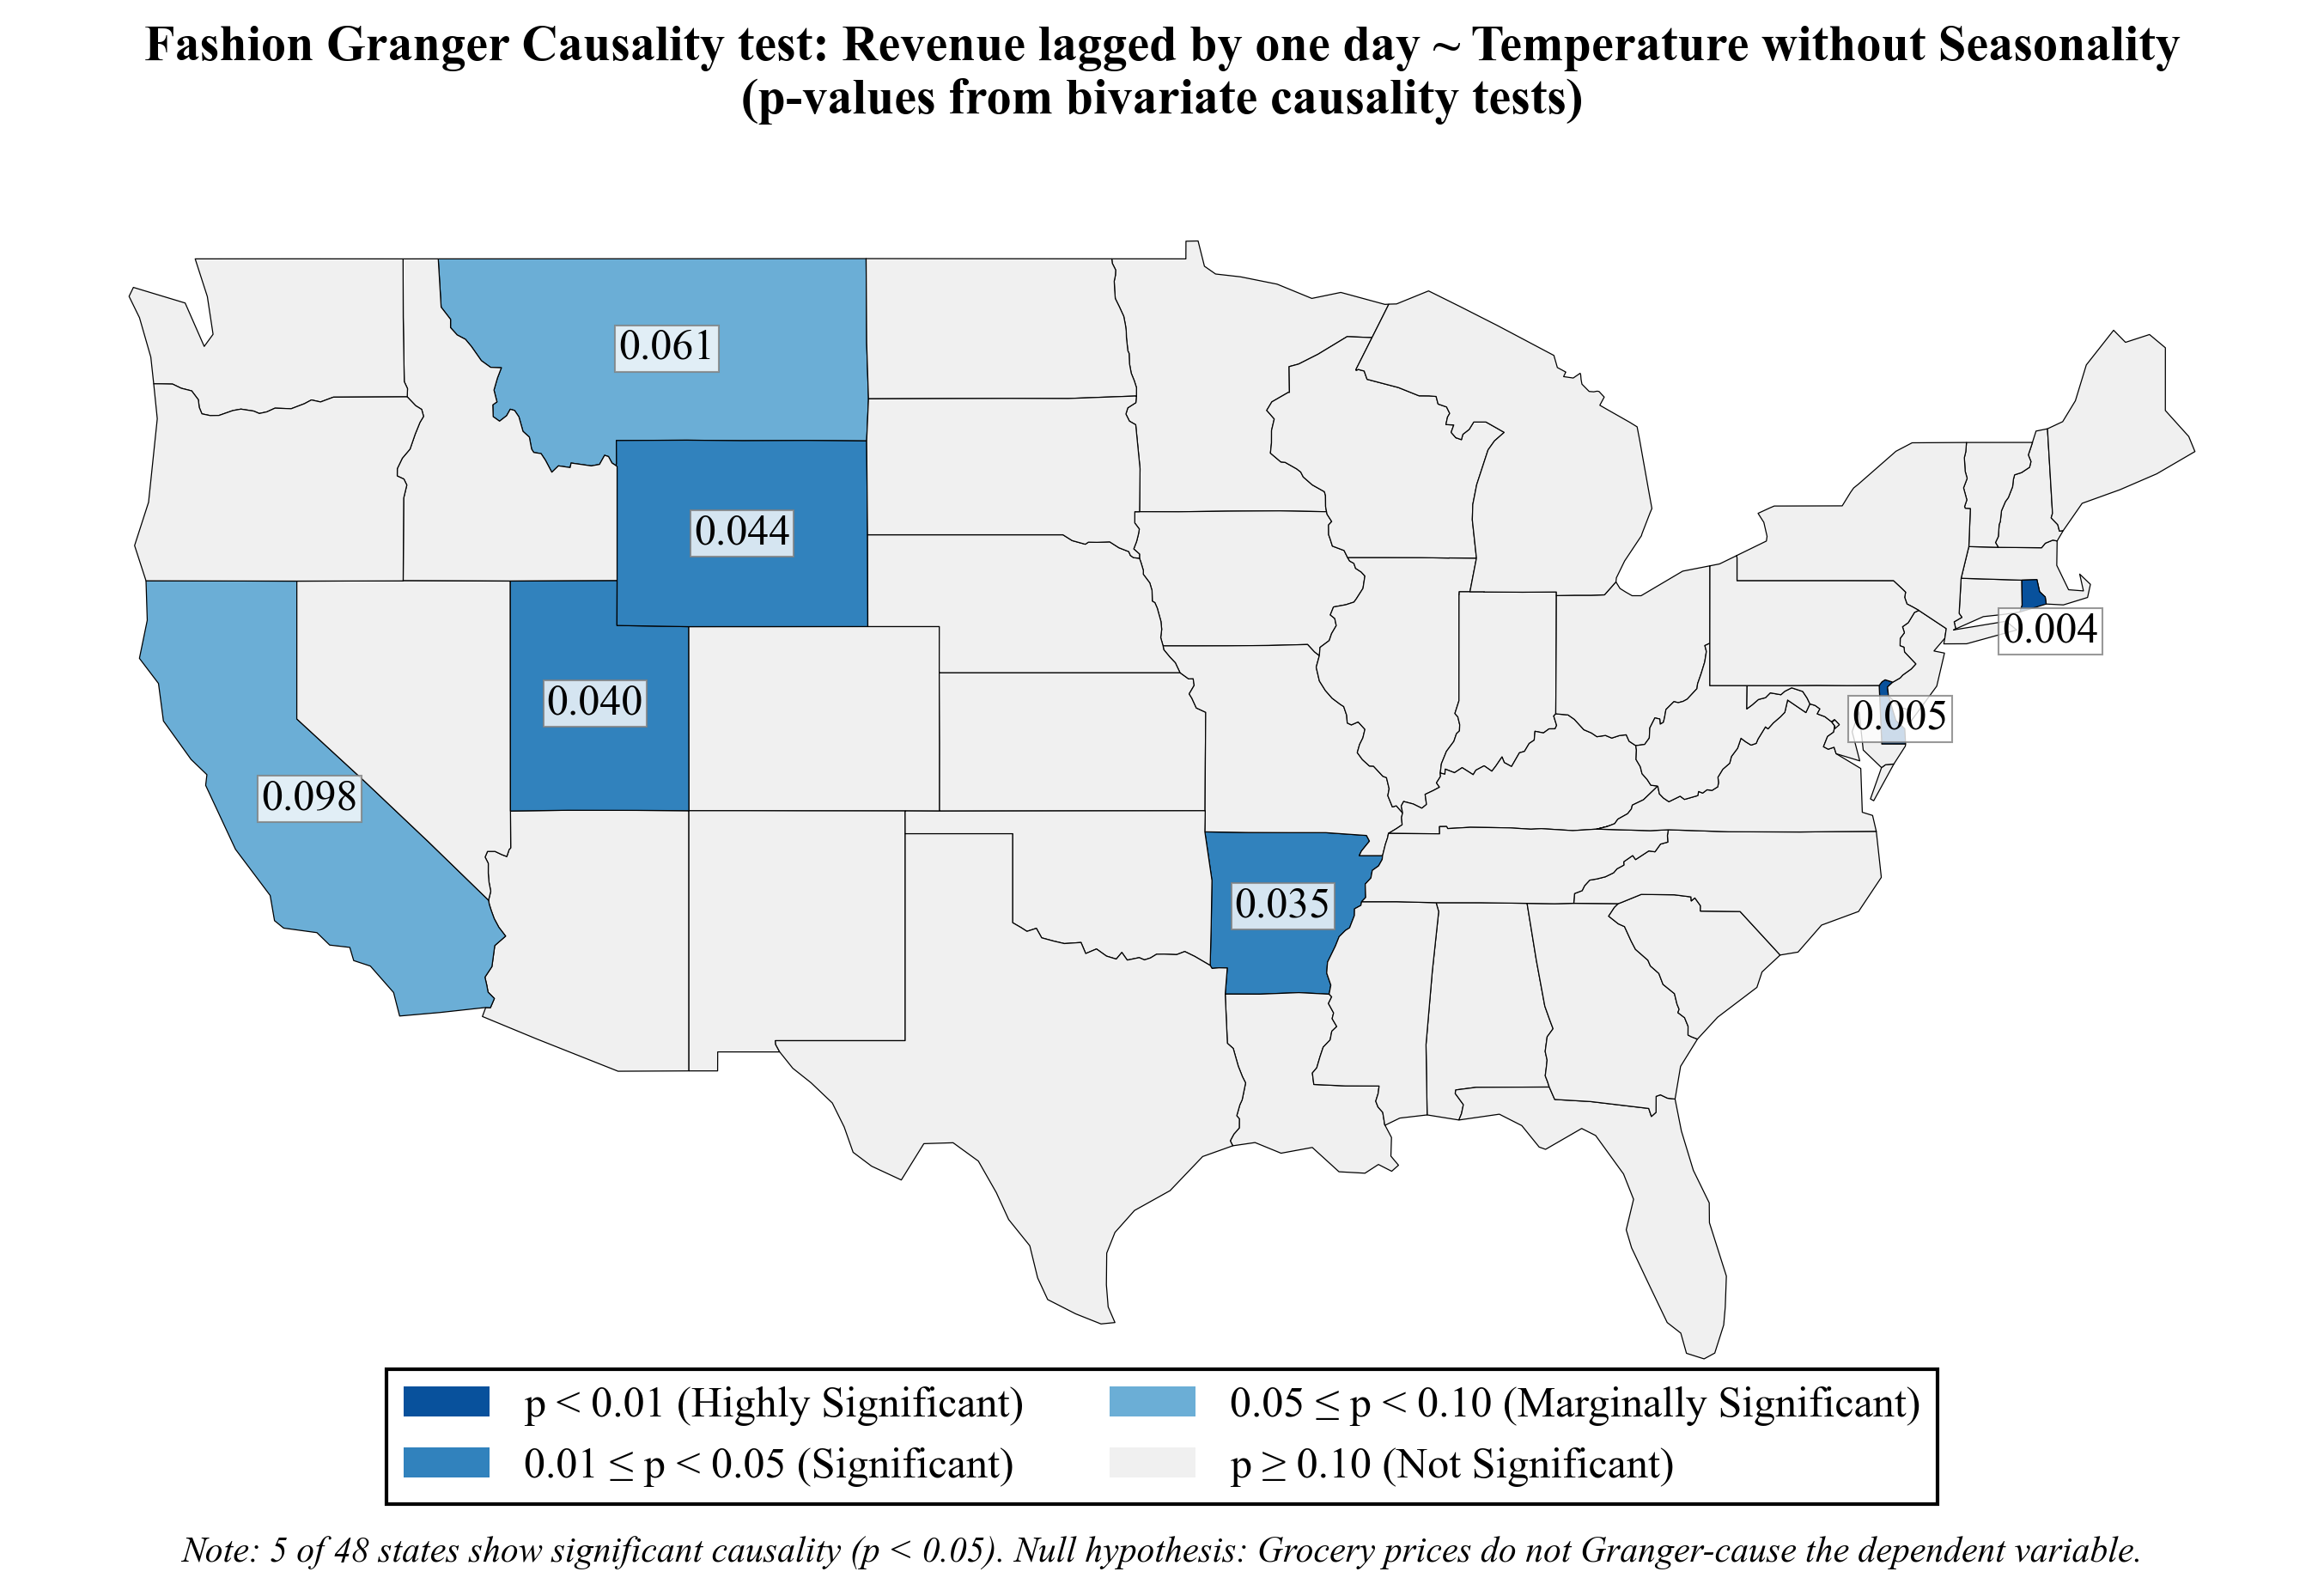

In [214]:
# Styling
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.linewidth': 0.8,
    'figure.dpi': 300
})

# Convert p-values to DataFrame
p_value_df = pd.DataFrame.from_dict(state_p_values_fashion, orient='index', columns=['p_value'])
p_value_df.index.name = 'state'

# Load and prepare geographic data
usa = gpd.read_file('./Map_USA/ne_110m_admin_1_states_provinces.shp')
usa = usa[~usa['postal'].isin(['AK', 'HI'])]  # Exclude Alaska and Hawaii
usa['state'] = usa['postal']
usa = usa.merge(p_value_df, on='state', how='left')

# Create figure with proper dimensions for academic publication
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Define significance levels and colors
significance_levels = [0, 0.01, 0.05, 0.10, 1.0]
colors = ['#08519c', '#3182bd', '#6baed6', '#f0f0f0']
cmap = plt.matplotlib.colors.ListedColormap(colors)
norm = BoundaryNorm(significance_levels, cmap.N)

# Create the choropleth map
usa.plot(column='p_value',
         cmap=cmap,
         norm=norm,
         ax=ax,
         legend=False,
         edgecolor='black',
         linewidth=0.3,
         missing_kwds={'color': '#f0f0f0', 'edgecolor': 'black', 'linewidth': 0.3})

# Define manual positions for overlapping East Coast states
manual_positions = {
    'CT': (-73, 41.8),    # Connecticut - move slightly east
    'RI': (-71.0, 40.9),    # Rhode Island - move east
    'MA': (-70.5, 42.5),    # Massachusetts - move northeast  
    'VT': (-72.8, 44.2),    # Vermont - move slightly west
    'NH': (-71.2, 43.8),    # New Hampshire - move east
    'NJ': (-74.0, 40.0),    # New Jersey - move south
    'DE': (-75.2, 39.0),    # Delaware - move southwest
    'MD': (-76.5, 39.2),    # Maryland - move west
}

# Add state labels with p-values (smaller, cleaner format)
for idx, row in usa.iterrows():
    if not pd.isna(row['p_value']):
        # Use manual position if available, otherwise use centroid
        if row['state'] in manual_positions:
            x, y = manual_positions[row['state']]
        else:
            centroid = row.geometry.centroid
            x, y = centroid.x, centroid.y
        
        # Only show p-value if it's significant or marginally significant
        if row['p_value'] <= 0.10:
            label = f'{row["p_value"]:.3f}'
            ax.text(x, y, 
                   label,
                   horizontalalignment='center',
                   verticalalignment='center',
                   fontsize=12,
                   fontweight='normal',
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', 
                           linewidth=0.5, pad=1))

# Create custom legend
legend_elements = [
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#08519c', label='p < 0.01 (Highly Significant)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#3182bd', label='0.01 ≤ p < 0.05 (Significant)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#6baed6', label='0.05 ≤ p < 0.10 (Marginally Significant)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#f0f0f0', label='p ≥ 0.10 (Not Significant)'),
    #mpatches.Rectangle((0, 0), 1, 1, facecolor='#f0f0f0', label='No Data')
]

# Position legend outside the plot area
legend = ax.legend(handles=legend_elements, 
                  loc='lower center',
                  bbox_to_anchor=(0.5, -0.09),  # Center horizontally, below the plot
                  ncol=2,  # Number of columns (adjust based on your legend items)
                  frameon=True,
                  fancybox=False,
                  shadow=False,
                  framealpha=1,
                  edgecolor='black',
                  facecolor='white')

# Set title with proper academic formatting
ax.set_title('Fashion Granger Causality test: Revenue lagged by one day ~ Temperature without Seasonality\n(p-values from bivariate causality tests)',
             fontsize=14, 
             fontweight='bold',
             pad=20)

# Remove axes
ax.set_axis_off()

# Add statistical summary as subtitle
total_states = len(usa[~usa['p_value'].isna()])
significant_states = len(usa[usa['p_value'] <= 0.05])
ax.text(0.5, -0.12, 
        f'Note: {significant_states} of {total_states} states show significant causality (p < 0.05). '
        f'Null hypothesis: Grocery prices do not Granger-cause the dependent variable.',
        transform=ax.transAxes,
        fontsize=10,
        ha='center',
        style='italic')

# Adjust layout to accommodate legend
plt.tight_layout()
plt.subplots_adjust(right=0.75)

# Save options for thesis
#plt.savefig('granger_causality_fashion.pdf', dpi=300, bbox_inches='tight')
plt.savefig('./Exports/granger_causality_fashion_temp_no_season.png', dpi=300, bbox_inches='tight')

plt.show()

## Groceries

In [215]:
state_p_values_grocerie = {}
p_values_grocieries_list = []

for i in range(len(states_list)): 
    try: 
        # Create subset of only one State
        df_one_state = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin([states_list[i]])].copy()

        # Remove Seasonality from Temperature
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

        df_one_state["Revenue_lagged1"] = df_one_state["Revenue"].shift(1)
        # Remove values for 2017; We only needed them for Removing Seasonality in 2018 and dont have transactiosn for that year
        df_one_state = df_one_state.iloc[365:, ]

        #Define first order Diff for Revenue
        first_order_diff = [0]

        # Calc first order diff
        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        # Append to main df 
        df_one_state["first_order_diff_Revenue"] = first_order_diff


        # Perfrom granger test on variables first order diff and temperature no season
        granger_matrix = grangers_causation_matrix(df_one_state ,variables=["Revenue_lagged1", "Temp_No_Season"])

        # Collect p-values from returned matrix
        p_value = granger_matrix.iloc[0, 1]

        # Save states p-value in final df
        state_p_values_grocerie[states_list[i]] = p_value
        p_values_grocieries_list.append(p_value)

        #print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    


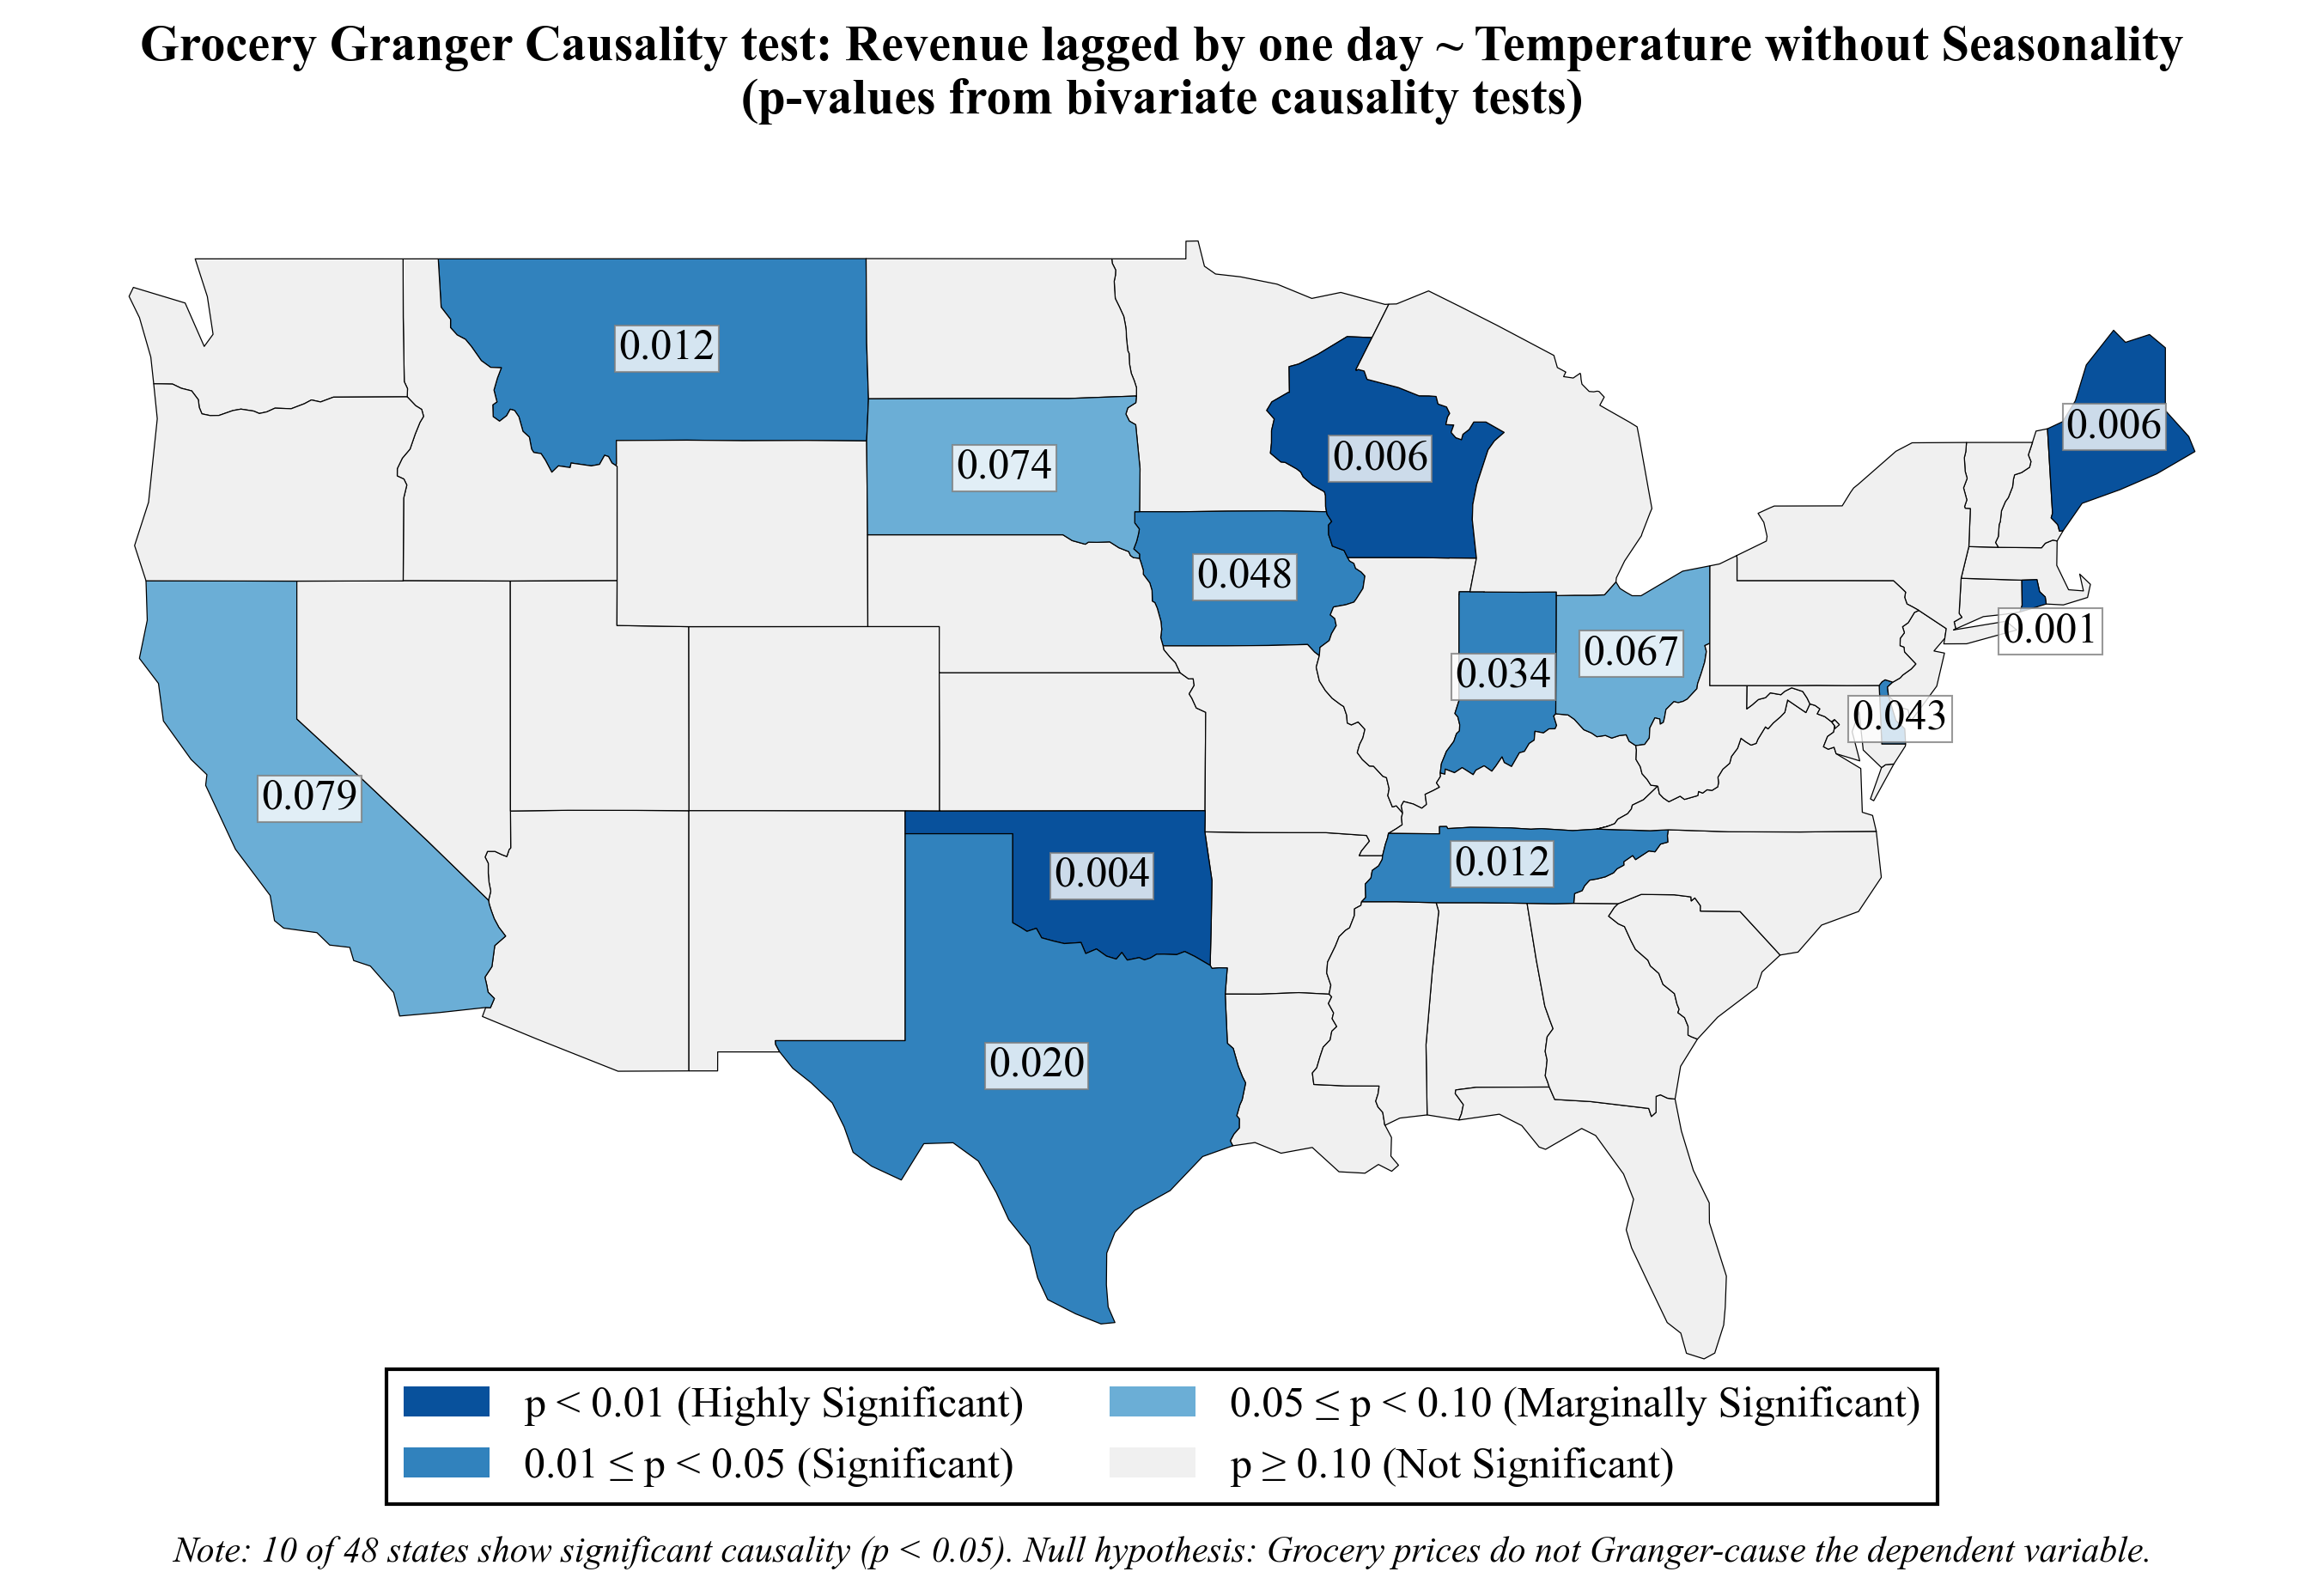

In [216]:
# Styling
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.linewidth': 0.8,
    'figure.dpi': 300
})

# Convert p-values to DataFrame
p_value_df = pd.DataFrame.from_dict(state_p_values_grocerie, orient='index', columns=['p_value'])
p_value_df.index.name = 'state'

# Load and prepare geographic data
usa = gpd.read_file('./Map_USA/ne_110m_admin_1_states_provinces.shp')
usa = usa[~usa['postal'].isin(['AK', 'HI'])]  # Exclude Alaska and Hawaii
usa['state'] = usa['postal']
usa = usa.merge(p_value_df, on='state', how='left')

# Create figure with proper dimensions for academic publication
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Define significance levels and colors
significance_levels = [0, 0.01, 0.05, 0.10, 1.0]
colors = ['#08519c', '#3182bd', '#6baed6', '#f0f0f0']
cmap = plt.matplotlib.colors.ListedColormap(colors)
norm = BoundaryNorm(significance_levels, cmap.N)

# Create the choropleth map
usa.plot(column='p_value',
         cmap=cmap,
         norm=norm,
         ax=ax,
         legend=False,
         edgecolor='black',
         linewidth=0.3,
         missing_kwds={'color': '#f0f0f0', 'edgecolor': 'black', 'linewidth': 0.3})

# Define manual positions for overlapping East Coast states
manual_positions = {
    'CT': (-73, 41.8),    # Connecticut - move slightly east
    'RI': (-71.0, 40.9),    # Rhode Island - move east
    'MA': (-70.5, 42.5),    # Massachusetts - move northeast  
    'VT': (-72.8, 44.2),    # Vermont - move slightly west
    'NH': (-71.2, 43.8),    # New Hampshire - move east
    'NJ': (-74.0, 40.0),    # New Jersey - move south
    'DE': (-75.2, 39.0),    # Delaware - move southwest
    'MD': (-76.5, 39.2),    # Maryland - move west
}

# Add state labels with p-values (smaller, cleaner format)
for idx, row in usa.iterrows():
    if not pd.isna(row['p_value']):
        # Use manual position if available, otherwise use centroid
        if row['state'] in manual_positions:
            x, y = manual_positions[row['state']]
        else:
            centroid = row.geometry.centroid
            x, y = centroid.x, centroid.y
        
        # Only show p-value if it's significant or marginally significant
        if row['p_value'] <= 0.10:
            label = f'{row["p_value"]:.3f}'
            ax.text(x, y, 
                   label,
                   horizontalalignment='center',
                   verticalalignment='center',
                   fontsize=12,
                   fontweight='normal',
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', 
                           linewidth=0.5, pad=1))

# Create custom legend
legend_elements = [
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#08519c', label='p < 0.01 (Highly Significant)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#3182bd', label='0.01 ≤ p < 0.05 (Significant)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#6baed6', label='0.05 ≤ p < 0.10 (Marginally Significant)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#f0f0f0', label='p ≥ 0.10 (Not Significant)'),
    #mpatches.Rectangle((0, 0), 1, 1, facecolor='#f0f0f0', label='No Data')
]

# Position legend outside the plot area
legend = ax.legend(handles=legend_elements, 
                  loc='lower center',
                  bbox_to_anchor=(0.5, -0.09),  # Center horizontally, below the plot
                  ncol=2,  # Number of columns (adjust based on your legend items)
                  frameon=True,
                  fancybox=False,
                  shadow=False,
                  framealpha=1,
                  edgecolor='black',
                  facecolor='white')

# Set title with proper academic formatting
ax.set_title('Grocery Granger Causality test: Revenue lagged by one day ~ Temperature without Seasonality\n(p-values from bivariate causality tests)',
             fontsize=14, 
             fontweight='bold',
             pad=20)

# Remove axes
ax.set_axis_off()

# Add statistical summary as subtitle
total_states = len(usa[~usa['p_value'].isna()])
significant_states = len(usa[usa['p_value'] <= 0.05])
ax.text(0.5, -0.12, 
        f'Note: {significant_states} of {total_states} states show significant causality (p < 0.05). '
        f'Null hypothesis: Grocery prices do not Granger-cause the dependent variable.',
        transform=ax.transAxes,
        fontsize=10,
        ha='center',
        style='italic')

# Adjust layout to accommodate legend
plt.tight_layout()
plt.subplots_adjust(right=0.75)

# Save options for thesis
#plt.savefig('granger_causality_groceries.pdf', dpi=300, bbox_inches='tight')
plt.savefig('./Exports/granger_causality_groceries_temp_no_season.png', dpi=300, bbox_inches='tight')

plt.show()

In [217]:
reject, adj_pvals = multipletests(p_values_grocieries_list, alpha=0.1, method='fdr_bh', is_sorted = False)[:2]
#print("Groceries Category \n")
#print(reject)
#print("-------------")
#print(adj_pvals)

state_p_values_grocerie_adj = {}
for i in range(len(states_list)): 
    state_p_values_grocerie_adj[states_list[i]] = adj_pvals[i]
    p_values_grocerie_adj_list = adj_pvals


reject, adj_pvals = multipletests(p_values_fashion_list, alpha=0.05, method='fdr_bh', is_sorted = False)[:2]
#print("\n Fashion Category\n")
#print(reject)
#print("-------------")
#print(adj_pvals)

state_p_values_fashion_adj = {}
for i in range(len(states_list)): 
    state_p_values_fashion_adj[states_list[i]] = adj_pvals[i]
    p_values_fashion_adj_list = adj_pvals

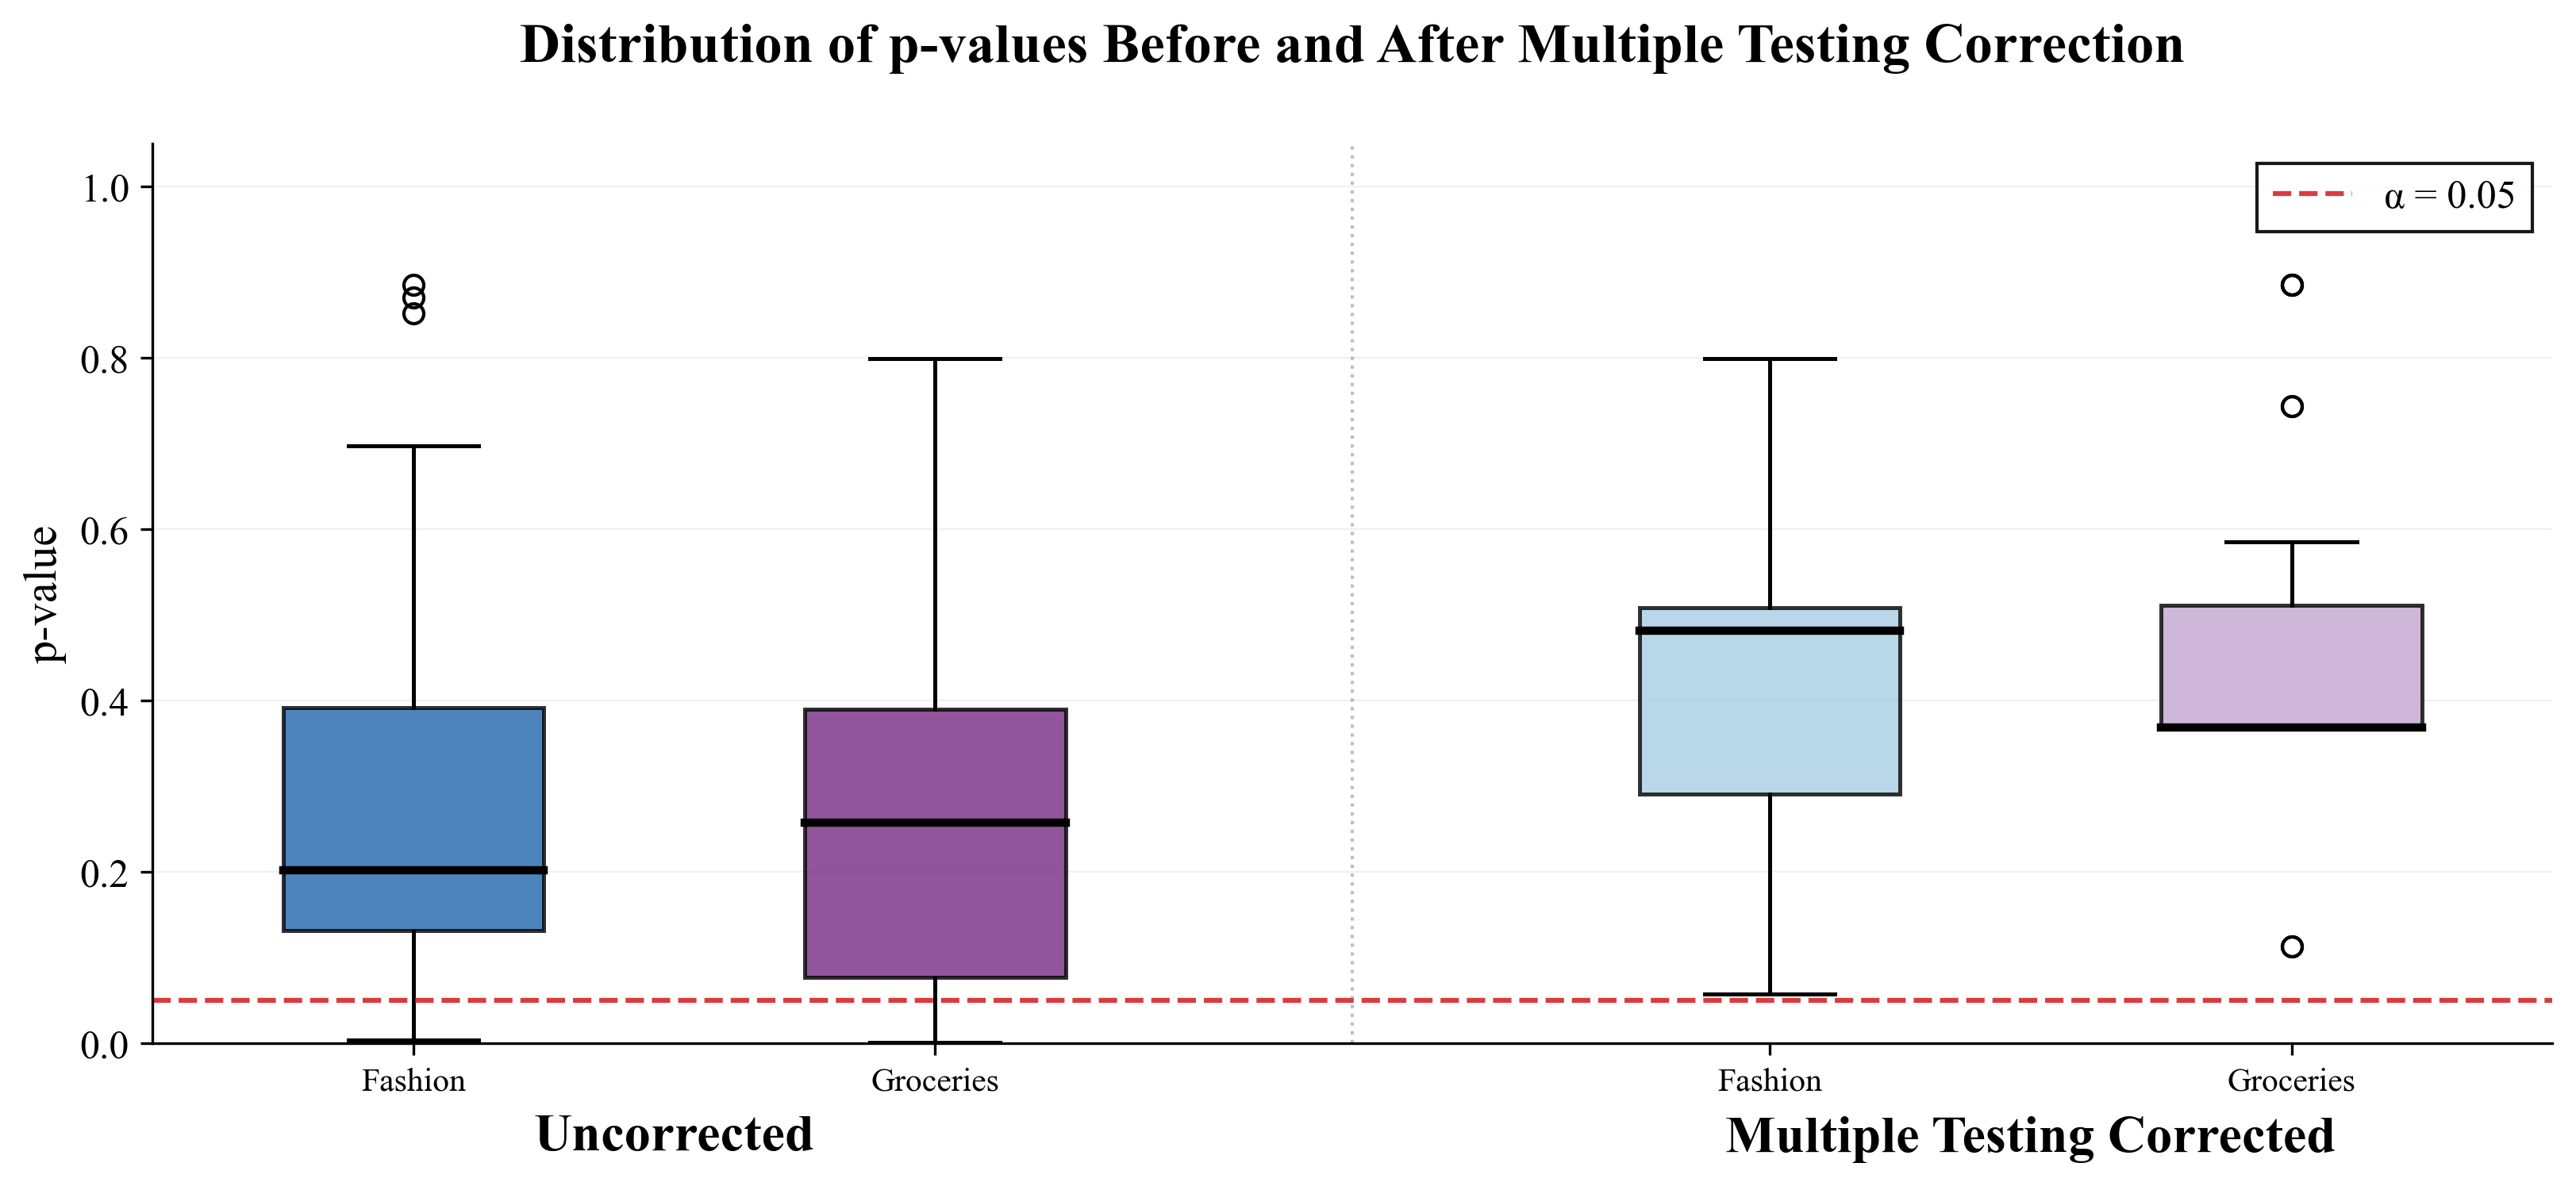

In [218]:
import matplotlib.pyplot as plt
import numpy as np

# Set publication-ready style
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.linewidth': 0.8,
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# FIXED: Increased figure width and adjusted positioning
fig, ax = plt.subplots(figsize=(12, 6))  # Increased from 10 to 12

# FIXED: Better positions that leave more margin on both sides
positions = [1.2, 2.2, 3.8, 4.8]  # More centered, more space on right
widths = 0.5

# Professional color scheme
colors = {
    'fashion_orig': '#2166ac',     # Professional blue
    'groceries_orig': '#762a83',   # Professional purple
    'groceries_adj': '#a6cee3',    # Light blue (adjusted)
    'fashion_adj': '#c2a5cf'       # Light purple (adjusted)
}

# Create boxplots with consistent styling
box_props = dict(linewidth=1.2, alpha=0.8)
median_props = dict(linewidth=2.5, color='black')
whisker_props = dict(linewidth=1.2)
cap_props = dict(linewidth=1.2)

bp1 = ax.boxplot([p_values_fashion_list], 
                 positions=[positions[0]], 
                 widths=widths,
                 patch_artist=True,
                 boxprops={**box_props, 'facecolor': colors['fashion_orig']},
                 medianprops=median_props,
                 whiskerprops=whisker_props,
                 capprops=cap_props)

bp2 = ax.boxplot([p_values_grocieries_list], 
                 positions=[positions[1]], 
                 widths=widths,
                 patch_artist=True,
                 boxprops={**box_props, 'facecolor': colors['groceries_orig']},
                 medianprops=median_props,
                 whiskerprops=whisker_props,
                 capprops=cap_props)

bp3 = ax.boxplot([p_values_fashion_adj_list], 
                 positions=[positions[3]], 
                 widths=widths,
                 patch_artist=True,
                 boxprops={**box_props, 'facecolor': colors['fashion_adj']},
                 medianprops=median_props,
                 whiskerprops=whisker_props,
                 capprops=cap_props)

bp4 = ax.boxplot([p_values_grocerie_adj_list], 
                 positions=[positions[2]], 
                 widths=widths,
                 patch_artist=True,
                 boxprops={**box_props, 'facecolor': colors['groceries_adj']},
                 medianprops=median_props,
                 whiskerprops=whisker_props,
                 capprops=cap_props)



# Professional labels and title
ax.set_ylabel('p-value', fontsize=14, fontweight='normal')
ax.set_title('Distribution of p-values Before and After Multiple Testing Correction', 
             fontsize=17, fontweight='bold', pad=25)

# Clean x-axis labels
labels = ['Fashion', 'Groceries', 'Fashion', 'Groceries']
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=10)

# Add significance threshold lines with better styling
ax.axhline(y=0.05, color='#d62728', linestyle='--', linewidth=1.5, alpha=0.9, label='α = 0.05')

# FIXED: Adjusted separator position for new positions
ax.axvline(x=3.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Professional legend
ax.legend(loc='upper right', frameon=True, fancybox=False, shadow=False, 
          framealpha=0.9, edgecolor='black', facecolor='white')

# Minimal grid
ax.grid(True, alpha=0.2, axis='y', linestyle='-', linewidth=0.5)

# Set appropriate y-axis limits
ax.set_ylim(0, 1.05)

# FIXED: Set x-axis limits explicitly to ensure proper margins
ax.set_xlim(0.7, 5.3)  # Gives proper margin on both sides

# FIXED: Adjusted group label positions
ax.text(1.7, -0.08, 'Uncorrected', ha='center', va='top', fontweight='bold', 
        transform=ax.get_xaxis_transform(), fontsize=16)
ax.text(4.3, -0.08, 'Multiple Testing Corrected', ha='center', va='top', fontweight='bold',
        transform=ax.get_xaxis_transform(), fontsize=16)

# Calculate and display summary statistics
fashion_median = np.median(p_values_fashion_list)
groceries_median = np.median(p_values_grocieries_list)
groceries_adj_median = np.median(p_values_grocerie_adj_list)
fashion_adj_median = np.median(p_values_fashion_adj_list)

# Count significant results
fashion_sig = np.sum(np.array(p_values_fashion_list) < 0.05)
groceries_sig = np.sum(np.array(p_values_grocieries_list) < 0.05)
groceries_adj_sig = np.sum(np.array(p_values_grocerie_adj_list) < 0.05)
fashion_adj_sig = np.sum(np.array(p_values_fashion_adj_list) < 0.05)

# FIXED: Better layout adjustment
plt.tight_layout()
plt.subplots_adjust(left=0.08, right=0.92, bottom=0.25, top=0.88)

# Save options for thesis
# plt.savefig('granger_causality_boxplots.pdf', dpi=300, bbox_inches='tight')
plt.savefig('./Exports/granger_causality_boxplots_temp_no_season.png', dpi=300, bbox_inches='tight', 
            pad_inches=0.2)  # Added pad_inches for extra safety

plt.show()

# STOP SECTION GRANGER CAUSALITY TEST

# Autocorrelation for first order Revenue lags

### Approach 1 (old)

In [219]:
"""series = df_one_state["first_order_diff_Revenue"]"""

'series = df_one_state["first_order_diff_Revenue"]'

In [220]:
"""plot_acf(series)
plt.show()

#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/"""

'plot_acf(series)\nplt.show()\n\n#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/'

Shows that if there was a purchase on t=0 it is less likley that someone is purchasing at t=1. Makes sense since when you bought something you are unlikley to buy something imeadiatly the next day. 

### Approach 3 (New)

In [221]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acf_results = {}

for state in states_list: 
    state_filter = fashion_df["Shipping Address State"] == state # Create subset for only one state
    df_one_state = fashion_df[state_filter]
    acf_values = acf(df_one_state["Revenue"], nlags=6)
    acf_results[state] = acf_values

# Create a plot
plt.figure(figsize=(12, 8))

# Plot ACF for each state
for state, acf_values in acf_results.items():
    plt.plot(range(1, len(acf_values)), acf_values[1:], label=state)

plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('ACF by State')

NameError: name 'fashion_df' is not defined

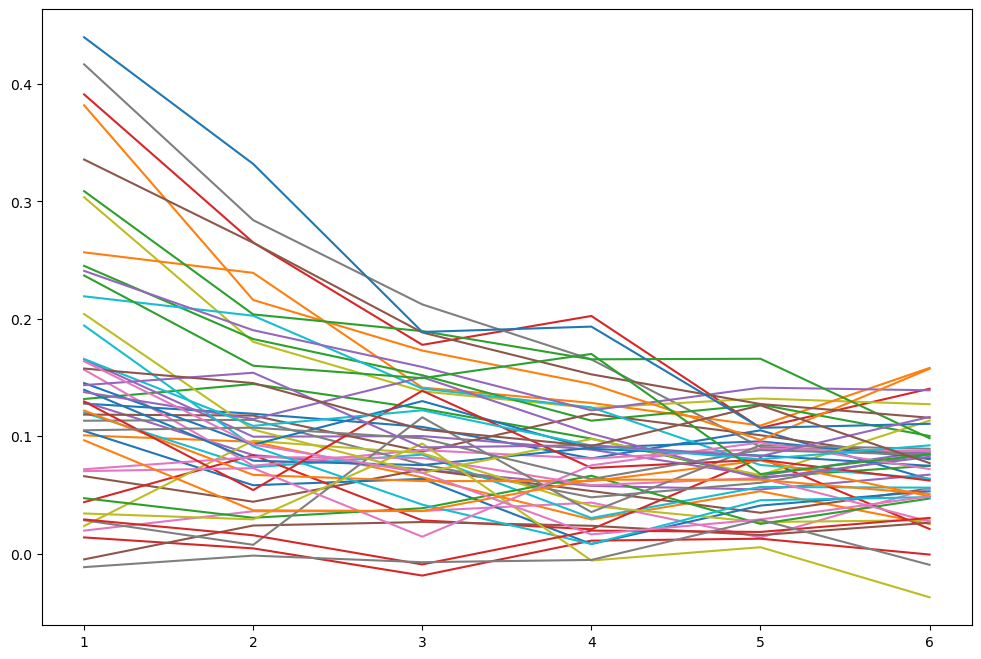

In [ ]:
pacf_results = {}

for state in states_list: 
    state_filter = fashion_df["Shipping Address State"] == state # Create subset for only one state
    df_one_state = fashion_df[state_filter]
    pacf_values = pacf(df_one_state["Revenue"], nlags=6)
    pacf_results[state] = pacf_values

# Create a plot
plt.figure(figsize=(12, 8))

# Plot ACF for each state
for state, pacf_values in pacf_results.items():
    plt.plot(range(1, len(pacf_values)), pacf_values[1:], label=state)

## Calculating the Autocorrleation using a combined revnue
When we split the revenue per state we get a lot of different results per state for the corrleation between the days. The assumption is that this is due to a lack of datadensity on a state level, leading to a lot of 0 values, which ultimatly influence our correlation resutls. 

Because of that we combine all the Fashion category revenue sources per day. This approach should allow us to achive the necessary datadensity needed to calculate an meaningfull autoccorlation between the days.

In [ ]:
for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])

C:\Users\morit\AppData\Local\Temp\ipykernel_11620\3034542748.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])


In [ ]:
import pandas as pd

# Take df of 
#1 subset 
#2 order 
#3 first order diff 
#4 Autocorrelation 


def autocorrelation_per_state(data): 
    states_list = data["Shipping Address State"].unique()
    results_df = pd.DataFrame(columns=['State', 't', 't+1','t+2','t+3','t+4','t+5','t+6'])

    for state in states_list: 
        # Filter for only one State
        state_filter = data["Shipping Address State"] == state # Create subset for only one state
        df_one_state = data[state_filter]

        # Order datapoints by date 
        df_one_state = df_one_state.sort_values("Order Date", ascending=True)

        # Calculate first order diff
        first_order_diff = [0]
        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])
        
        df_one_state["first_order_diff_Revenue"] = first_order_diff

        # Calculate autocorrelation
        series = df_one_state["first_order_diff_Revenue"]

        # using shift function to shift the values.
        dataframe = pd.concat([series.shift(6), series.shift(5), series.shift(4), series.shift(3), series.shift(2), series.shift(1), series], axis=1)
        # naming the columns
        dataframe.columns = ['t', 't+1', 't+2', 't+3', 't+4', 't+5', 't+6']

        # using corr() function to compute the correlation
        result = dataframe.corr()
        new_row = {"State": state, "t": result.iloc[0,0], "t+1": result.iloc[0,1], "t+2": result.iloc[0,2], "t+3": result.iloc[0,3], "t+4": result.iloc[0,4], "t+5": result.iloc[0,5], "t+6": result.iloc[0,6]}
        results_df.loc[len(results_df)] = new_row

    return results_df

In [ ]:
# Fashion combined
data = fashion_df.sort_values("Order Date", ascending=True)

fashion_df_combined = data.groupby(["Order Date"]).agg({"Revenue": "sum"})


fashion_df_combined["Revenue"] = fashion_df_combined["Revenue"].round(2)

fashion_df_combined.reset_index("Order Date", inplace=True)

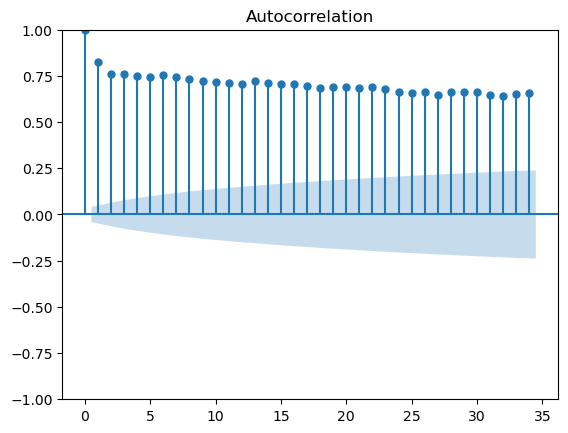

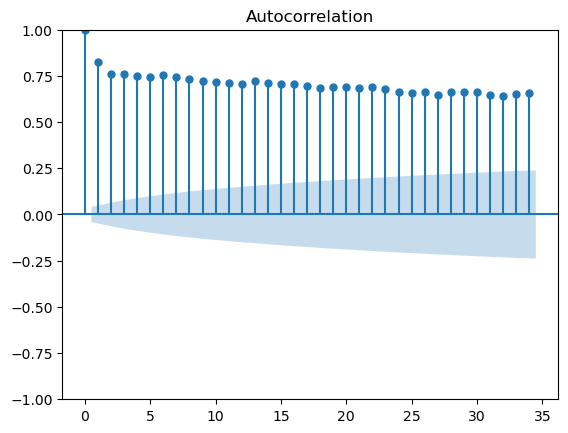

In [ ]:
acf_values = acf(fashion_df_combined["Revenue"])

plot_acf(fashion_df_combined["Revenue"])
#plt.plot(range(1, len(acf_values)), acf_values[1:])

c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


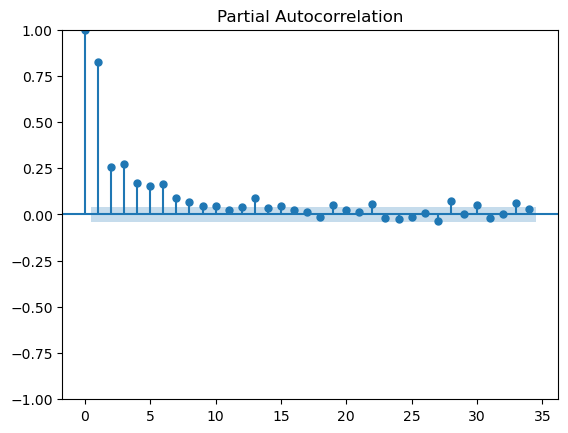

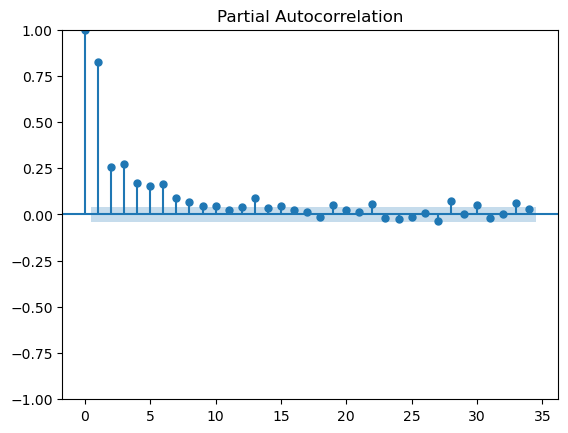

In [ ]:
pacf_values = pacf(fashion_df_combined["Revenue"])
plot_pacf(fashion_df_combined["Revenue"])

#plt.plot(range(1, len(pacf_values)), pacf_values[1:])

### Fashion

In [ ]:
#from utils.autocorrelation_per_state import autocorrelation_per_state

correlation_df = autocorrelation_per_state(fashion_df)
correlation_df.set_index('State', inplace=True)
correlation_df.head()

,t,t+1,t+2,t+3,t+4,t+5,t+6
State,,,,,,,
AL,1.0,-0.503654,0.002827,0.009869,-0.025171,0.033582,-0.031790
AR,1.0,-0.502067,0.014063,0.005458,-0.029363,0.025862,-0.045893
AZ,1.0,-0.515986,0.017966,0.004349,0.006319,-0.020023,0.005826
CA,1.0,-0.489015,0.009465,-0.051122,0.066014,-0.059265,0.026052
CO,1.0,-0.482796,-0.013490,0.001836,-0.005166,-0.008826,-0.006984


Text(95.72222222222221, 0.5, 'State')

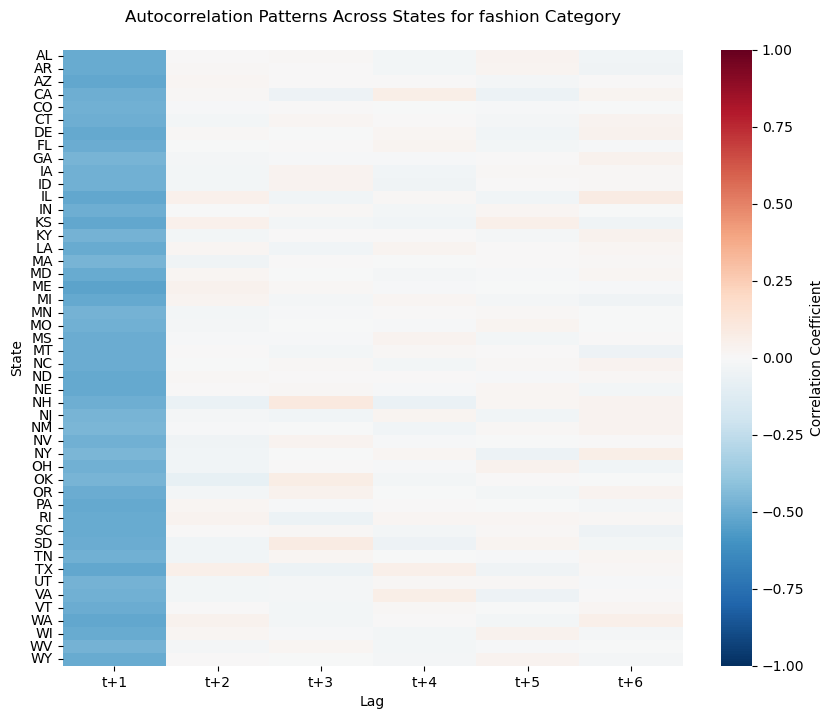

In [ ]:
df_heatmap = correlation_df.iloc[:,1:] 

figsize=(10, 8) 
# Create figure and axes
plt.figure(figsize=figsize)

# Create heatmap
sns.heatmap(df_heatmap,
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,       # Center the colormap at 0
            vmin=-1,       # Minimum correlation value
            vmax=1,        # Maximum correlation value
            cbar_kws={'label': 'Correlation Coefficient'},
            xticklabels=True,
            yticklabels=True)

plt.title('Autocorrelation Patterns Across States for fashion Category', pad=20)
plt.xlabel('Lag')
plt.ylabel('State')

Basically there is only siginificant correlation between t and t+1

### Groceries

In [ ]:
correlation_df = autocorrelation_per_state(groceries_df)
correlation_df.set_index('State', inplace=True)

Text(95.72222222222221, 0.5, 'State')

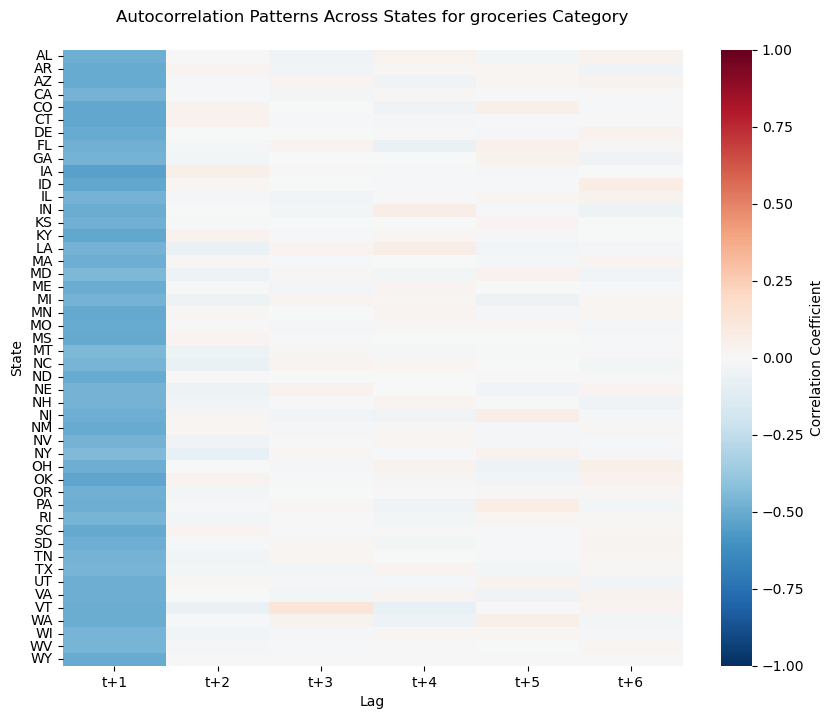

In [ ]:
df_heatmap = correlation_df.iloc[:,1:] 
figsize=(10, 8) 
# Create figure and axes
plt.figure(figsize=figsize)

# Create heatmap
sns.heatmap(df_heatmap,
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,       # Center the colormap at 0
            vmin=-1,       # Minimum correlation value
            vmax=1,        # Maximum correlation value
            cbar_kws={'label': 'Correlation Coefficient'},
            xticklabels=True,
            yticklabels=True)

plt.title('Autocorrelation Patterns Across States for groceries Category', pad=20)
plt.xlabel('Lag')
plt.ylabel('State')

# Testing with granger causality
We could also included the granger test for Temp_No_Season -> Revenue as it seems to be performing quite good

In [ ]:
state_p_values_grocerie = {}

for i in range(len(states_list)): 
    try: 
        # Create subset of only one State
        df_one_state = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin([states_list[i]])].copy()

        # Remove Seasonality from Temperature
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

        # Remove values for 2017; We only needed them for Removing Seasonality in 2018 and dont have transactiosn for that year
        df_one_state = df_one_state.iloc[365:, ]

        #Define first order Diff for Revenue
        first_order_diff = [0]

        # Calc first order diff
        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        # Append to main df 
        df_one_state["first_order_diff_Revenue"] = first_order_diff


        # Perfrom granger test on variables first order diff and temperature no season
        granger_matrix = grangers_causation_matrix(df_one_state ,variables=["Revenue", "Temp_No_Season"])

        # Collect p-values from returned matrix
        p_value = granger_matrix.iloc[0, 1]

        # Save states p-value in final df
        state_p_values_grocerie[states_list[i]] = p_value

        print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    


For the state AL temperature as a predictor has a p-value of: 0.3658
For the state AR temperature as a predictor has a p-value of: 0.2873
For the state AZ temperature as a predictor has a p-value of: 0.2293
For the state CA temperature as a predictor has a p-value of: 0.1632
For the state CO temperature as a predictor has a p-value of: 0.3293
For the state CT temperature as a predictor has a p-value of: 0.2042
For the state DE temperature as a predictor has a p-value of: 0.0227
For the state FL temperature as a predictor has a p-value of: 0.7153
For the state GA temperature as a predictor has a p-value of: 0.2872
For the state IA temperature as a predictor has a p-value of: 0.1723
For the state ID temperature as a predictor has a p-value of: 0.2687
For the state IL temperature as a predictor has a p-value of: 0.683
For the state IN temperature as a predictor has a p-value of: 0.0477
For the state KS temperature as a predictor has a p-value of: 0.2379
For the state KY temperature as a p

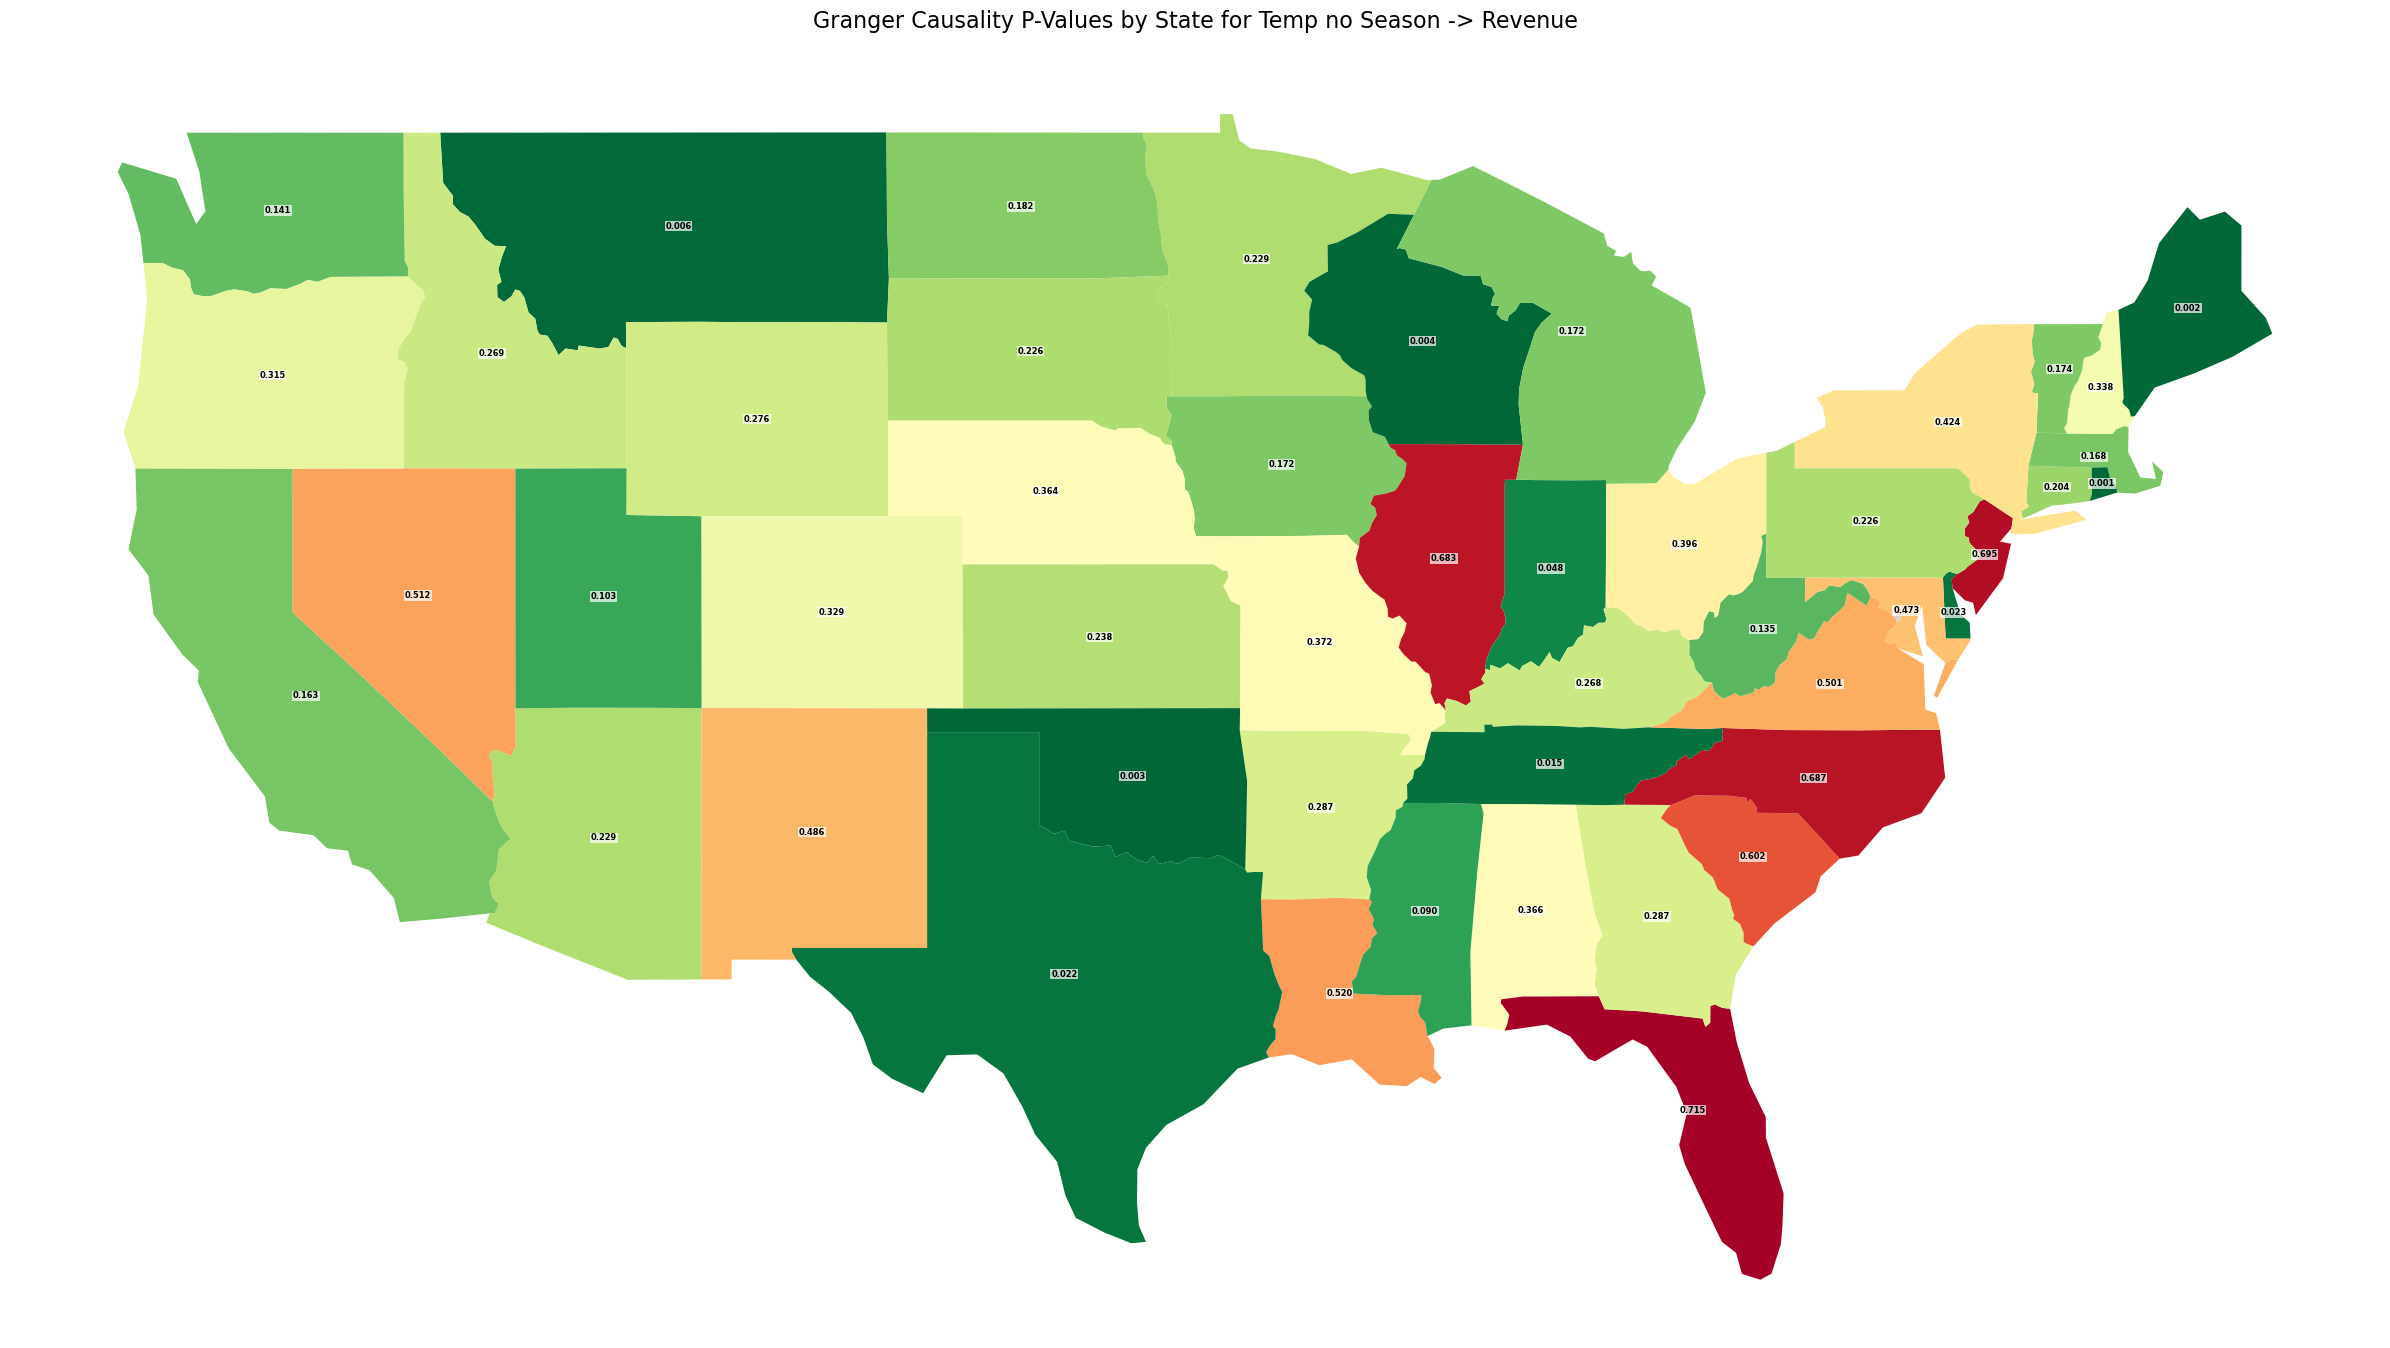

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Convert p-values to DataFrame
p_value_df = pd.DataFrame.from_dict(state_p_values_grocerie, orient='index', columns=['p_value'])
p_value_df.index.name = 'state'

# Load US states shapefile - CORRECTED URL
# Replace the read_file line with:
usa = gpd.read_file('./data/Map_USA/ne_110m_admin_1_states_provinces.shp')
usa = usa[~usa['postal'].isin(['AK', 'HI'])]

# Convert state codes
usa['state'] = usa['postal']  # Updated from 'STUSPS' to 'postal' which is the correct column name in current Natural Earth Data

# Rest of your code remains the same
usa = usa.merge(p_value_df, on='state', how='left')

fig = plt.figure(figsize=(24, 14))
ax = fig.add_subplot(111)
cmap = plt.cm.RdYlGn_r

usa.plot(column='p_value',
         cmap=cmap,
         ax=ax,
         legend=False,
         missing_kwds={'color': 'lightgrey'})

for idx, row in usa.iterrows():
    if not pd.isna(row['p_value']):
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, 
                f'{row["p_value"]:.3f}',
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=6,
                fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

plt.title('Granger Causality P-Values by State for Temp no Season -> Revenue', fontsize=16, pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()